# ERCOT Houston Hub — Exploratory Data Analysis

**Purpose:** Understand the structure, drivers, and predictability of RTM price volatility at Houston Hub before modeling.

**Contents:**
1. **Setup** — load `ercot_combined.parquet`, define constants and helper functions
2. **Target variable** — distribution, time series, spike rate, threshold selection (\$100/MWh)
3. **Feature EDA** — net load, wind error, forecast revision std, DAM price, ancillary prices; correlation with log-volatility; non-linear effects
4. **Regime analysis** — Winter Storm Uri (Feb 2021), seasonal/diurnal concentration, autocorrelation of volatility
5. **Modeling roadmap and further feature EDA** — D+1 leakage rule, validation strategy, data design

**Appendices (end of notebook):**
- **Feature Dictionary** — 22 base features (v3 adds GARCH + 7 engineered features in modeling.ipynb, totalling 30) defined by category, source dataset, and leakage status
- **Cross-feature EDA** - pruning some features which display strong relationships with others
- **Feature Matrix Audit** — leakage audit results, training matrix statistics, DST note

**Data range:** 2017-07-01 → 2025-12-31 (hourly, ~74,000 rows)  
**Train**: 2017-07 → 2024-12 · **Test**: 2025 · **Hold-out**: 2026 (do not load)

**Input:** `ercot_combined.parquet` (built by `data_cleaning.ipynb`). Feature parquets written at end of §5.  
**Continue in:** `modeling.ipynb` for all model training, evaluation, and drift analysis.

---

**Key findings (forward reference — details in sections below):**
- **§2:** `log1p(rtm_price_std)` reduces skewness from 20.55 → 2.10; spike rate \~3% above \\$100/MWh (\~p97); Winter Storm Uri (Feb 2021) produced extreme spikes (>\\$1,000/MWh) not representative of normal market — see §2.4 for threshold justification
- **§3:** `dam_price_houston` is the single strongest predictor of RTM volatility; `wind_error_houston` and `fc_net_load` add incremental signal; non-linear effects dominate (motivates XGBoost over Ridge) — see §3 correlation heatmap
- **§4:** Post-Uri (2021+) volatility distribution shifted structurally — pre/post regimes are not exchangeable; training on post-Uri data alone outperforms full history (confirmed in modeling.ipynb §7.5)
- **§5:** Midnight CST prediction cutoff enforced throughout; load/RTM/wind actuals require D-2 lag (48h); DAM prices are safe as D+1 features (~12:35 CST) — see feature leakage audit in Appendix B

## 1. Setup

Load the pre-processed combined dataset (`ercot_combined.parquet`). This wide table aligns all 9 ERCOT datasets by delivery hour (`ts_cst`), enabling exploratory analysis of how market prices, load, wind, and ancillary services co-vary over time.

> **Note**: `ercot_combined` is for EDA only. Model features are built separately using `build_features()` with a leakage-safe **midnight CST cutoff** (see Section 5.3 and `modeling.ipynb`).

In [1]:
try:
    get_ipython().run_line_magic('matplotlib', 'inline')
except NameError:
    pass  # not running in Jupyter

from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import seaborn as sns
from scipy import stats

PROCESSED_ROOT = Path('data/processed/ercot')
Path('figures/eda').mkdir(parents=True, exist_ok=True)

plt.rcParams.update({'figure.dpi': 120, 'font.size': 10})
plt.rcParams['figure.max_open_warning'] = 50
sns.set_style('whitegrid')

# EDA exploration threshold — used only to count extreme spikes in EDA section 2
# The model's binary target uses spike_flag = (rtm_price_mean > 100)

print('Imports OK')


Imports OK


In [2]:
# ── Missing data check ──────────────────────────────────────────────────────
# Run before any analysis. Checks the combined EDA table for timestamp gaps and nulls.

_combined = pd.read_parquet(PROCESSED_ROOT / 'ercot_combined.parquet')

# 1. Timestamp gaps in combined (should be hourly 2017-07 → 2025-12)
_full_ts = pd.date_range(_combined['ts_cst'].min(), _combined['ts_cst'].max(), freq='h')
_missing_ts = _full_ts.difference(_combined['ts_cst'])
print(f"ercot_combined.parquet: {len(_combined):,} rows | expected {len(_full_ts):,} | missing ts: {len(_missing_ts)}")
if len(_missing_ts):
    print(f"  Missing: {list(_missing_ts)}")

# 2. Null counts in combined (top offenders only)
_nulls = _combined.isnull().sum()
_nulls = _nulls[_nulls > 0].sort_values(ascending=False)
print(f"\nNulls in ercot_combined ({len(_nulls)} columns with nulls):")
print(_nulls.head(20).to_string())

del _combined, _full_ts, _missing_ts, _nulls

ercot_combined.parquet: 74,569 rows | expected 74,569 | missing ts: 0

Nulls in ercot_combined (52 columns with nulls):
mcpc_ecrs                            52104
houston_irr_mw                       34266
houston_resource_mw                  34266
houston_re_share                     34266
net_load_mw                            176
total_irr_mw                           128
total_resource_mw                      128
re_share                               128
outf_total_irr_mw_std_48h              121
outf_total_resource_mw                 121
outf_total_resource_mw_std_48h         121
outf_total_irr_mw                      121
dam_rtm_spread_houston                  95
dam_rtm_spread_avg                      95
dam_price_houston                       95
dam_price_avg                           95
gen_lz_south_houston                    74
wgrpp_lz_south_houston                  74
wind_error_houston                      74
wf_stwpf_lz_south_houston_std_48h       50


In [3]:
df = pd.read_parquet(PROCESSED_ROOT / 'ercot_combined.parquet')
df['ts_cst'] = pd.to_datetime(df['ts_cst'])
df = df.sort_values('ts_cst').reset_index(drop=True)

print(f'Rows: {len(df):,}  |  Columns: {len(df.columns)}')
print(f'Range: {df.ts_cst.min()} -> {df.ts_cst.max()}')
print(f'\nColumns:\n{list(df.columns)}')

Rows: 74,569  |  Columns: 58
Range: 2017-06-29 23:00:00 -> 2025-12-31 23:00:00

Columns:
['ts_cst', 'load_houston', 'load_total', 'wz_coast', 'wz_east', 'wz_far_west', 'wz_north', 'wz_north_c', 'wz_southern', 'wz_south_c', 'wz_west', 'wz_total', 'rtm_price_max_hb_busavg', 'rtm_price_max_hb_houston', 'rtm_price_mean_hb_busavg', 'rtm_price_mean_hb_houston', 'rtm_price_min_hb_busavg', 'rtm_price_min_hb_houston', 'rtm_price_std_hb_busavg', 'rtm_price_std_hb_houston', 'dam_price_houston', 'dam_price_avg', 'system_lambda', 'total_resource_mw', 'total_irr_mw', 're_share', 'houston_resource_mw', 'houston_irr_mw', 'houston_re_share', 'outf_horizon_h', 'outf_total_resource_mw', 'outf_total_irr_mw', 'outf_total_resource_mw_std_48h', 'outf_total_irr_mw_std_48h', 'mcpc_ecrs', 'mcpc_nspin', 'mcpc_regdn', 'mcpc_regup', 'mcpc_rrs', 'fc_horizon_h', 'fc_coast', 'fc_system_total', 'fc_coast_std_48h', 'fc_system_total_std_48h', 'wf_horizon_h', 'wf_stwpf_lz_south_houston', 'wf_stwpf_lz_south_houston_std_48

In [4]:
df['abs_dam_rtm_spread_houston'] = np.absolute(df['dam_rtm_spread_houston'])

## 2. Target Variable: RTM Price Volatility

**Modeling goal**: predict *how volatile* RTM prices will be for a given delivery hour — before that hour arrives. This enables energy traders and grid operators to anticipate uncertainty in real-time market prices.

**Primary target**: `rtm_price_std_hb_houston` — std dev of **5 price points** at Houston Hub: the 4 intra-hour 15-min RTM settlement prices (p1–p4) plus the boundary point p0 (= the last 15-min price of the preceding hour). Including p0 captures inter-hour price jumps — a large move between hours is realized volatility from the perspective of a position spanning that boundary.  
High std = price moved a lot within (and into) that hour = realized intra-hour volatility.  
The distribution is heavily right-skewed (skewness=20.55); we use `log1p` transform for regression.

**Why `log1p` transform?**
- **Variance stabilization**: electricity volatility has multiplicative structure — a "2× spike day" means errors scale with the level. In log space, these become additive and residuals are closer to homoscedastic, satisfying OLS/XGBoost error assumptions better.
- **Skewness reduction**: raw skewness=20.55 → log1p skewness=2.10 (see distribution plot below). Extreme spike hours no longer dominate the loss function during training.
- **Zero safety**: `log1p` handles zero-std hours (rare, ~0.1%) without special cases; `log(x)` would be undefined.
- **Interpretability**: RMSE on log scale ≈ average log-ratio error; back-transforming predictions gives dollar-denominated evaluation (see §6 leaderboard).

**Secondary target**: `spike_flag` — binary indicator for hours where `rtm_price_mean > $100/MWh`.

### Why not use the DAM-RTM spread as the target?

The DAM-RTM spread (`dam_price - rtm_price_mean`) is genuinely a measure of uncertainty — a large spread means the market got the price level wrong, which is informative in its own right. Many market participants (e.g., financial traders taking positions across DAM and RTM) would care about this at least as much as intra-hour volatility.

The practical reason we target `spike_flag` and `log_rtm_std` instead is a **consumer-facing design choice**: retail consumers and grid operators care most about whether prices will be extremely high — a \$300/MWh hour is a cost shock regardless of whether it was volatile or stable around that level. `spike_flag` (RTM mean > \$100/MWh) directly captures that exposure. `log_rtm_std` captures *how uncertain* each hour is within its price level.

The spread, by contrast, measures *forecast error* — it can be large in both high and low price hours (if DAM was simply wrong), and can be small in a highly volatile hour (if DAM happened to match the RTM mean). As a standalone *target* it answers a different question: "how well did the DAM forecast the average RTM price?" rather than "how extreme or uncertain will this hour be for a consumer?"

`dam_rtm_spread` is included as a **feature** in our model (Section 3.4), where it adds signal precisely because level mispricing co-occurs with volatility — but it is not the right primary target for a consumer-risk model.

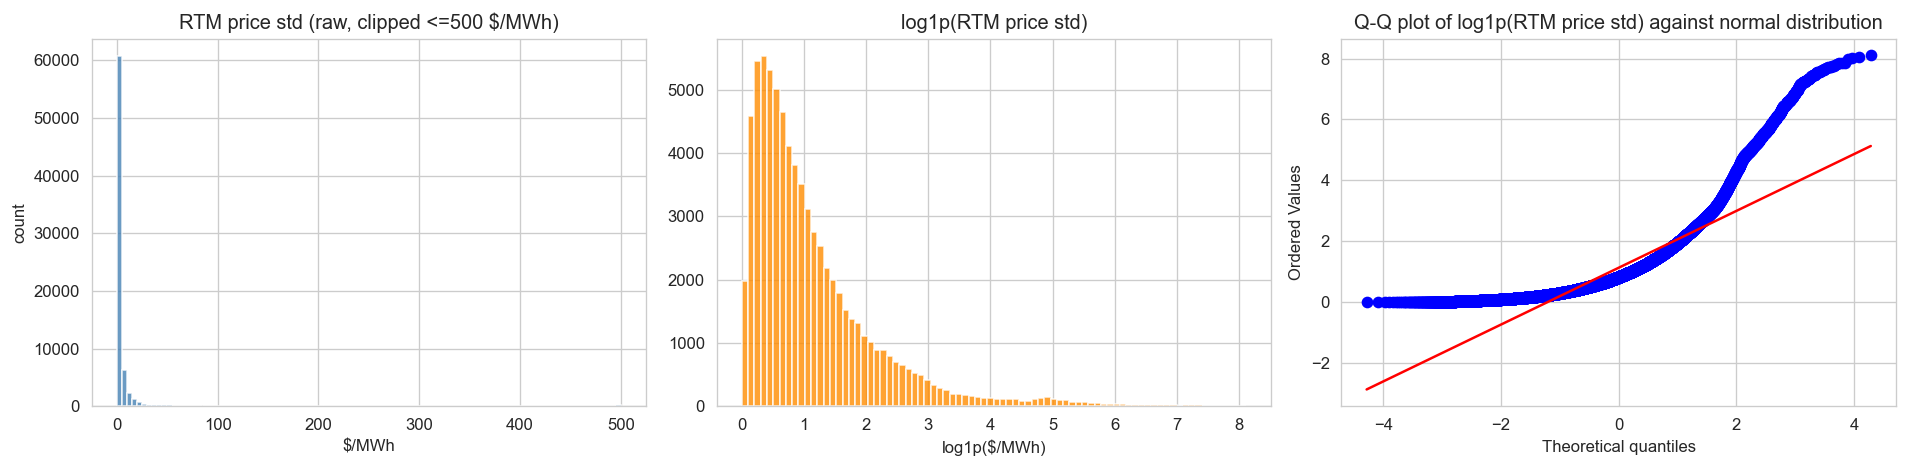

Raw:    mean=10.3  median=1.3  p95=21.6  p99=178.7  max=3320.0
Skewness (raw): 20.55  |  skewness (log1p): 2.10


In [5]:
# Distribution of RTM price std
_vol = df['rtm_price_std_hb_houston'].dropna()
_log_vol = np.log1p(_vol)

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

axes[0].hist(_vol.clip(upper=500), bins=100, color='steelblue', alpha=0.8)
axes[0].set_title('RTM price std (raw, clipped <=500 $/MWh)')
axes[0].set_xlabel('$/MWh'); axes[0].set_ylabel('count')

axes[1].hist(_log_vol, bins=80, color='darkorange', alpha=0.8)
axes[1].set_title('log1p(RTM price std)')
axes[1].set_xlabel('log1p($/MWh)')

stats.probplot(_log_vol, dist='norm', plot=axes[2])
axes[2].set_title('Q-Q plot of log1p(RTM price std) against normal distribution')

plt.tight_layout()
plt.show()

print(f'Raw:    mean={_vol.mean():.1f}  median={_vol.median():.1f}  '
      f'p95={_vol.quantile(.95):.1f}  p99={_vol.quantile(.99):.1f}  '
      f'max={_vol.max():.1f}')
print(f'Skewness (raw): {_vol.skew():.2f}  |  skewness (log1p): {_log_vol.skew():.2f}')

We examine RTM volatility through four complementary views: (1) distribution shape and log-transform justification, (2) full time series to show regime shifts, (3) diurnal and seasonal patterns, and (4) spike rate by hour and month.


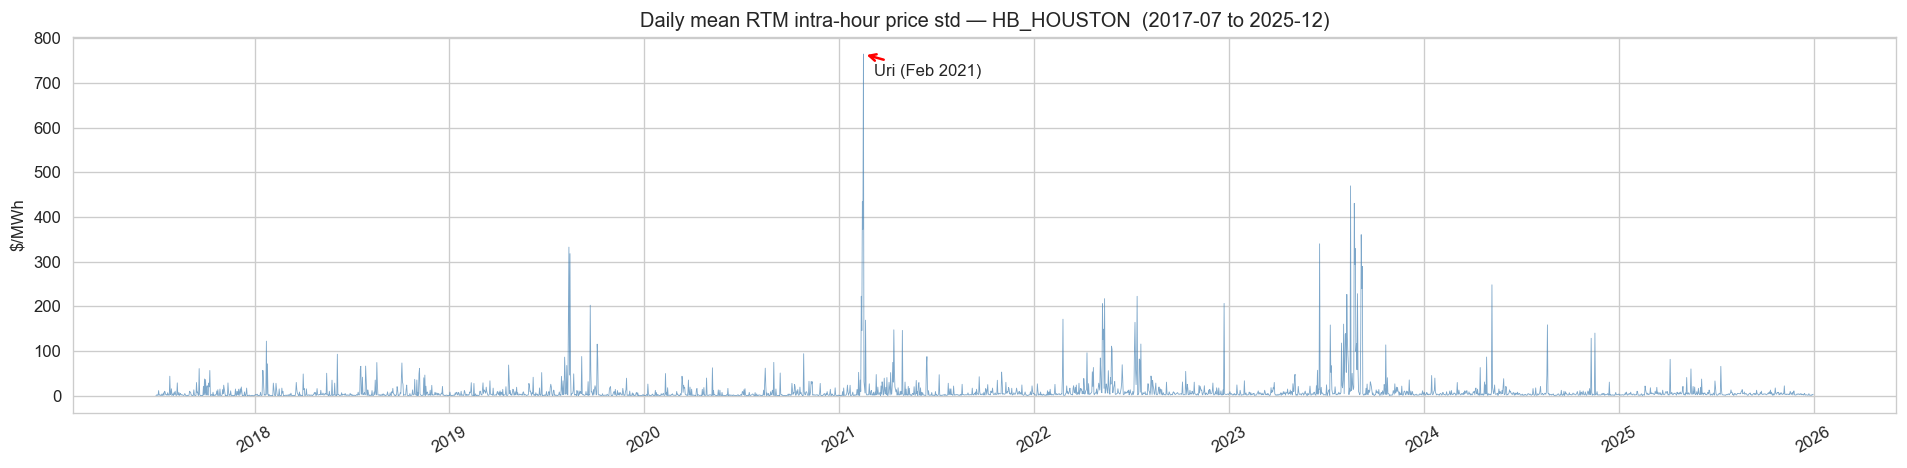

In [6]:
# Full time series of RTM volatility (daily mean)
_daily_vol = (
    df.set_index('ts_cst')['rtm_price_std_hb_houston']
      .resample('D').mean()
)

uri_value = _daily_vol.max()
uri_date = _daily_vol.idxmax()

fig, ax = plt.subplots(figsize=(16, 4))
ax.plot(_daily_vol.index, _daily_vol.values, lw=0.5, color='steelblue', alpha=0.7)
ax.annotate('Uri (Feb 2021)', xy=(uri_date, uri_value), xytext=(uri_date+ pd.Timedelta(20, "D"), uri_value-50),
            textcoords="data", arrowprops=dict(arrowstyle="->", color='red', lw=1.5), ha='left')
ax.set_title('Daily mean RTM intra-hour price std — HB_HOUSTON  (2017-07 to 2025-12)')
ax.set_ylabel('$/MWh')
ax.xaxis.set_major_locator(mdates.YearLocator())
ax.xaxis.set_major_formatter(mdates.DateFormatter('%Y'))
ax.tick_params(axis='x', rotation=30)
plt.tight_layout()
plt.show()

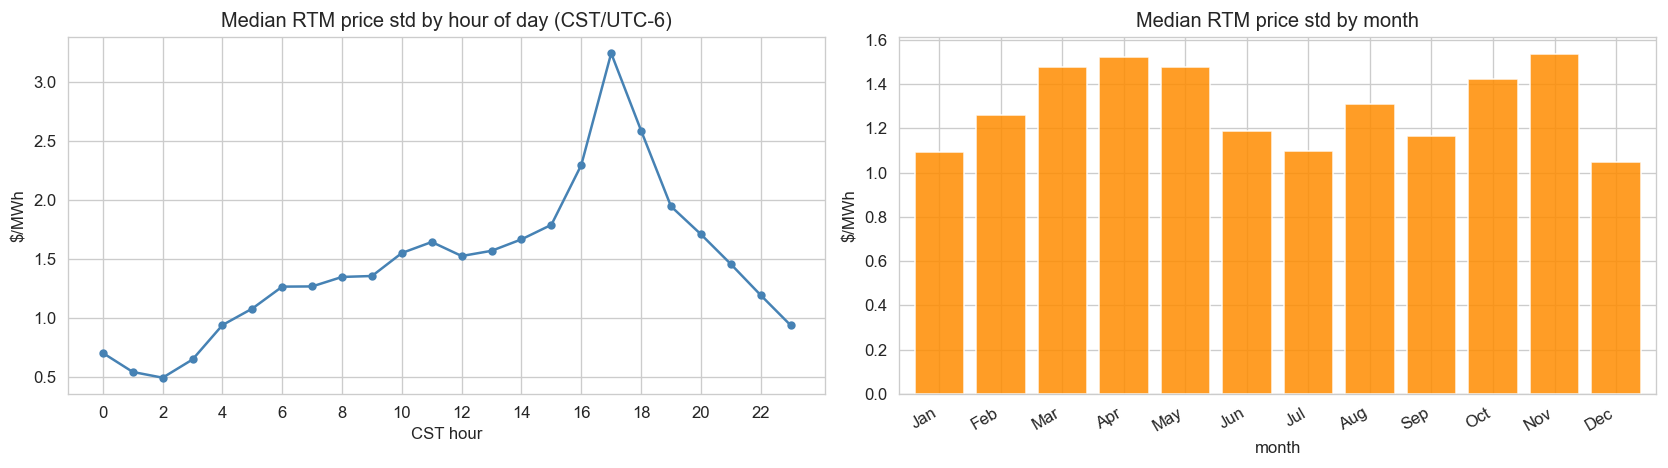

In [7]:
# Diurnal and seasonal volatility patterns
_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

df.groupby('hour')['rtm_price_std_hb_houston'].median().plot(
    ax=axes[0], marker='o', ms=4, lw=1.5, color='steelblue')
axes[0].set_title('Median RTM price std by hour of day (CST/UTC-6)')
axes[0].set_xlabel('CST hour'); axes[0].set_ylabel('$/MWh')
axes[0].set_xticks(range(0, 24, 2))

df.groupby('month')['rtm_price_std_hb_houston'].median().plot(
    kind='bar', ax=axes[1], color='darkorange', alpha=0.85, width=0.8)
axes[1].set_title('Median RTM price std by month')
axes[1].set_xticklabels(_months, rotation=30, ha='right')
axes[1].set_ylabel('$/MWh')

plt.tight_layout()
plt.show()

### 2.4 Spike Threshold Selection

To define the binary classification target `spike_flag`, we need to choose a threshold on `rtm_price_mean`.

**Why \$100/MWh:**
1. Falls at approximately the 97th percentile of RTM prices — unambiguously extreme
2. Provides ~2,400 positive training hours (out of ~65,000) — sufficient for XGBoost to learn patterns
3. Captures both curtailment events (\\$100–\\$500) and extreme scarcity (\$500+)
4. Operationally meaningful: \$100/MWh is commonly used in energy markets as the "scarcity pricing" signal

Candidate thresholds and actual spike rates are computed in the cell below (with CDF visualization).

Threshold exploration:
  RTM mean >    50 $/MWh:   9,243 hours  (12.40%)  ~p88
  RTM mean >   100 $/MWh:   2,334 hours  (3.13%)  ~p97
  RTM mean >   200 $/MWh:   1,037 hours  (1.39%)  ~p99
  RTM mean >   500 $/MWh:     516 hours  (0.69%)  ~p99
  RTM mean >  1000 $/MWh:     327 hours  (0.44%)  ~p100

p95  = $79/MWh
p97  = $103/MWh
p99  = $296/MWh
p999 = $8946/MWh

>> MODEL binary target: spike_flag = (rtm_price_mean > $100/MWh)  [chosen threshold]


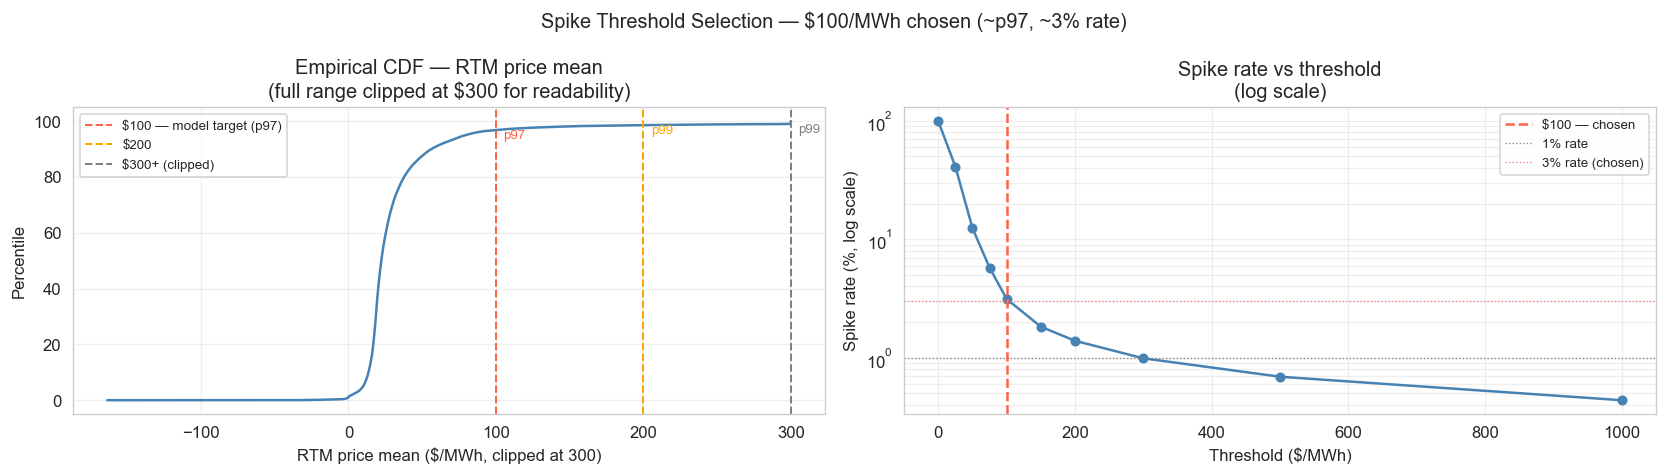


Uri-class extreme spikes (>$500/MWh, not the model target):
  -> 516 hours  (0.692%)


In [8]:
# Spike threshold selection — rates and CDF visualization
import numpy as np
import matplotlib.pyplot as plt

_rtm = df['rtm_price_mean_hb_houston'].dropna()

print("Threshold exploration:")
for thr in [50, 100, 200, 500, 1000]:
    n = (_rtm > thr).sum()
    pct = _rtm.quantile(1 - n / len(_rtm))
    print(f'  RTM mean > {thr:>5} $/MWh:  {n:>6,} hours  ({100*n/len(_rtm):.2f}%)  ~p{100*(1 - n/len(_rtm)):.0f}')

print(f'\np95  = ${_rtm.quantile(.95):.0f}/MWh')
print(f'p97  = ${_rtm.quantile(.97):.0f}/MWh')
print(f'p99  = ${_rtm.quantile(.99):.0f}/MWh')
print(f'p999 = ${_rtm.quantile(.999):.0f}/MWh')
print(f'\n>> MODEL binary target: spike_flag = (rtm_price_mean > $100/MWh)  [chosen threshold]')

# ── CDF plot (clipped at $300 for readability; log-scale inset for extremes) ──
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

# Left: ECDF clipped at $300
_clip = _rtm.clip(upper=300)
_sorted = np.sort(_clip)
_ecdf   = np.arange(1, len(_sorted) + 1) / len(_sorted)

axes[0].plot(_sorted, _ecdf * 100, lw=1.5, color='steelblue')
for thr, color, label in [(100, 'tomato', '$100 — model target (p97)'),
                           (200, 'orange', '$200'),
                           (300, 'gray',   '$300+ (clipped)')]:
    axes[0].axvline(thr, color=color, lw=1.2, ls='--', label=label)
    pct_val = (_rtm <= thr).mean() * 100
    axes[0].annotate(f'p{pct_val:.0f}', xy=(thr, pct_val), xytext=(thr + 5, pct_val - 3),
                     fontsize=8, color=color)
axes[0].set_xlabel('RTM price mean (\\$/MWh, clipped at 300)')
axes[0].set_ylabel('Percentile')
axes[0].set_title('Empirical CDF — RTM price mean\n(full range clipped at $300 for readability)')
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: spike rate by threshold (log y-axis)
thresholds = [0, 25, 50, 75, 100, 150, 200, 300, 500, 1000]
rates = [100* (_rtm > t).mean() for t in thresholds]
axes[1].plot(thresholds, rates, 'o-', color='steelblue', lw=1.5, ms=5)
axes[1].axvline(100, color='tomato', lw=1.5, ls='--', label='$100 — chosen')
axes[1].axhline(1.0, color='gray', lw=0.8, ls=':', label='1% rate')
axes[1].axhline(3.0, color='lightcoral', lw=0.8, ls=':', label='3% rate (chosen)')
axes[1].set_yscale('log')
axes[1].set_xlabel('Threshold ($/MWh)')
axes[1].set_ylabel('Spike rate (%, log scale)')
axes[1].set_title('Spike rate vs threshold\n(log scale)')
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3, which='both')

plt.suptitle('Spike Threshold Selection — $100/MWh chosen (~p97, ~3% rate)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/eda/spike_threshold_selection.png', dpi=150, bbox_inches='tight')
plt.show()

# For reference: Uri-class extreme events (>$500/MWh) — NOT the model target
print(f'\nUri-class extreme spikes (>$500/MWh, not the model target):')
print(f'  -> {(_rtm > 500).sum():,} hours  ({100*(_rtm > 500).mean():.3f}%)')

## 3. Feature EDA

### 3.0 Feature Correlations

We first display a correlation matrix of the numerical data, as well as their correlations with the target variable. We will investigate a few of these relationships in depth in this section, and then we will come back to this later in Appendix B once we have pruned some of the columns.

In [9]:
df['log_rtm_std'] = np.log1p(df['rtm_price_std_hb_houston'])
df['log_rtm_std_tomorrow'] = df['log_rtm_std'].shift(-24)

In [10]:
with pd.option_context('display.max_rows', None, 'display.max_columns', None, 'display.max_colwidth', None):
    display(np.trunc(df.corr(numeric_only = True) * 10**4) / 10**4)

,load_houston,load_total,wz_coast,wz_east,wz_far_west,wz_north,wz_north_c,wz_southern,wz_south_c,wz_west,wz_total,rtm_price_max_hb_busavg,rtm_price_max_hb_houston,rtm_price_mean_hb_busavg,rtm_price_mean_hb_houston,rtm_price_min_hb_busavg,rtm_price_min_hb_houston,rtm_price_std_hb_busavg,rtm_price_std_hb_houston,dam_price_houston,dam_price_avg,system_lambda,total_resource_mw,total_irr_mw,re_share,houston_resource_mw,houston_irr_mw,houston_re_share,outf_horizon_h,outf_total_resource_mw,outf_total_irr_mw,outf_total_resource_mw_std_48h,outf_total_irr_mw_std_48h,mcpc_ecrs,mcpc_nspin,mcpc_regdn,mcpc_regup,mcpc_rrs,fc_horizon_h,fc_coast,fc_system_total,fc_coast_std_48h,fc_system_total_std_48h,wf_horizon_h,wf_stwpf_lz_south_houston,wf_stwpf_lz_south_houston_std_48h,gen_lz_south_houston,wgrpp_lz_south_houston,wind_error_houston,dam_rtm_spread_houston,dam_rtm_spread_avg,net_load_mw,hour,month,weekday,is_peak,abs_dam_rtm_spread_houston,log_rtm_std,log_rtm_std_tomorrow
load_houston,1.0000,0.9396,0.9999,0.8489,0.3551,0.6859,0.8441,0.9263,0.9182,0.7218,0.9396,0.0491,0.0573,0.0244,0.0303,0.0012,0.0049,0.1269,0.1373,0.0443,0.0400,0.0400,-0.3674,0.1684,0.4185,-0.2480,0.0394,0.1707,0.3006,-0.3719,0.1563,-0.0215,0.0155,0.2063,-0.0051,-0.0285,-0.0181,-0.0285,0.3006,0.9793,0.9296,0.2523,0.2266,0.3005,0.1200,-0.1192,0.1612,0.1431,0.0139,0.0219,0.0263,0.9470,0.3006,0.1130,-0.0702,0.0383,0.1218,0.3311,0.2903
load_total,0.9396,1.0000,0.9395,0.9221,0.4928,0.8355,0.9378,0.9323,0.9814,0.7991,0.9999,0.0972,0.1017,0.0745,0.0778,0.0514,0.0534,0.1398,0.1446,0.0960,0.0932,0.0937,-0.4014,0.3019,0.5193,-0.2819,0.0899,0.2530,0.3081,-0.4075,0.2822,0.0069,0.1168,0.2083,0.0445,0.0097,0.0297,0.0230,0.3081,0.9398,0.9914,0.3169,0.3199,0.3081,0.1518,-0.0972,0.1932,0.1870,-0.0072,0.0213,0.0232,0.9868,0.3081,0.0740,-0.0621,0.0458,0.1495,0.3461,0.3117
wz_coast,0.9999,0.9395,1.0000,0.8488,0.3550,0.6858,0.8440,0.9262,0.9181,0.7217,0.9395,0.0490,0.0572,0.0243,0.0302,0.0011,0.0048,0.1269,0.1373,0.0442,0.0399,0.0399,-0.3673,0.1682,0.4184,-0.2479,0.0394,0.1707,0.3005,-0.3718,0.1562,-0.0215,0.0154,0.2062,-0.0051,-0.0285,-0.0182,-0.0286,0.3005,0.9793,0.9294,0.2523,0.2265,0.3005,0.1200,-0.1192,0.1612,0.1431,0.0139,0.0219,0.0263,0.9469,0.3005,0.1131,-0.0702,0.0383,0.1218,0.3311,0.2903
wz_east,0.8489,0.9221,0.8488,1.0000,0.2578,0.6896,0.9502,0.8264,0.9187,0.8350,0.9221,0.1535,0.1573,0.1318,0.1346,0.1083,0.1098,0.1592,0.1639,0.1577,0.1551,0.1560,-0.4438,0.2219,0.5020,-0.3351,0.0477,0.2423,0.3034,-0.4574,0.1829,-0.0164,0.1280,0.2343,0.1054,0.0557,0.0876,0.0859,0.3034,0.8530,0.9170,0.3039,0.3474,0.3034,0.0802,-0.0910,0.1181,0.0994,0.0244,0.0206,0.0221,0.9195,0.3035,0.0334,-0.0783,0.0329,0.1913,0.3409,0.3015
wz_far_west,0.3551,0.4928,0.3550,0.2578,1.0000,0.7742,0.2548,0.4141,0.4313,0.1124,0.4928,-0.0543,-0.0546,-0.0592,-0.0594,-0.0627,-0.0627,-0.0015,-0.0036,-0.0603,-0.0598,-0.0598,0.0347,0.6020,0.3576,0.1147,0.2362,0.2072,0.0275,0.0499,0.6500,0.0985,0.1876,-0.1674,-0.0726,-0.0623,-0.0747,-0.0821,0.0274,0.3543,0.4853,0.1786,0.1446,0.0273,0.2287,-0.0035,0.2349,0.2813,-0.1297,0.0090,0.0098,0.4096,0.0274,0.0516,0.0008,-0.0063,-0.0293,0.1458,0.1573
wz_north,0.6859,0.8355,0.6858,0.6896,0.7742,1.0000,0.7195,0.7216,0.7815,0.5524,0.8355,0.0548,0.0554,0.0423,0.0428,0.0292,0.0294,0.0771,0.0767,0.0562,0.0559,0.0563,-0.2571,0.4439,0.4799,-0.1887,0.1270,0.2550,0.1697,-0.2541,0.4528,0.0714,0.1791,0.0883,0.0200,-0.0007,0.0093,0.0044,0.1696,0.6938,0.8278,0.3052,0.3074,0.1696,0.1434,-0.0570,0.1733,0.2117,-0.0264,0.0183,0.0189,0.7921,0.1696,0.0691,-0.0274,0.0042,0.0808,0.2500,0.2445
wz_north_c,0.8441,0.9378,0.8440,0.9502,0.2548,0.7195,1.0000,0.8253,0.9218,0.8573,0.9378,0.1441,0.1463,0.1217,0.1234,0.0977,0.0987,0.1584,0.1600,0.1448,0.1427,0.1438,-0.4935,0.1707,0.5051,-0.3619,0.0388,0.2523,0.3061,-0.5053,0.1294,-0.0122,0.1071,0.2279,0.0929,0.0485,0.0777,0.0744,0.3061,0.8539,0.9292,0.2970,0.3347,0.3061,0.0912,-0.0951,0.1343,0.1180,0.0317,0.0192,0.0192,0.9446,0.3062,0.0360,-0.0676,0.0434,0.1818,0.3188,0.2806


### 3.1 Net Load — Primary Driver of Price Volatility

`net_load = system_load − wind_generation`. High net load means thermal generators must ramp up, increasing marginal cost and price volatility. Low net load (high wind penetration) can cause negative prices or curtailment events.


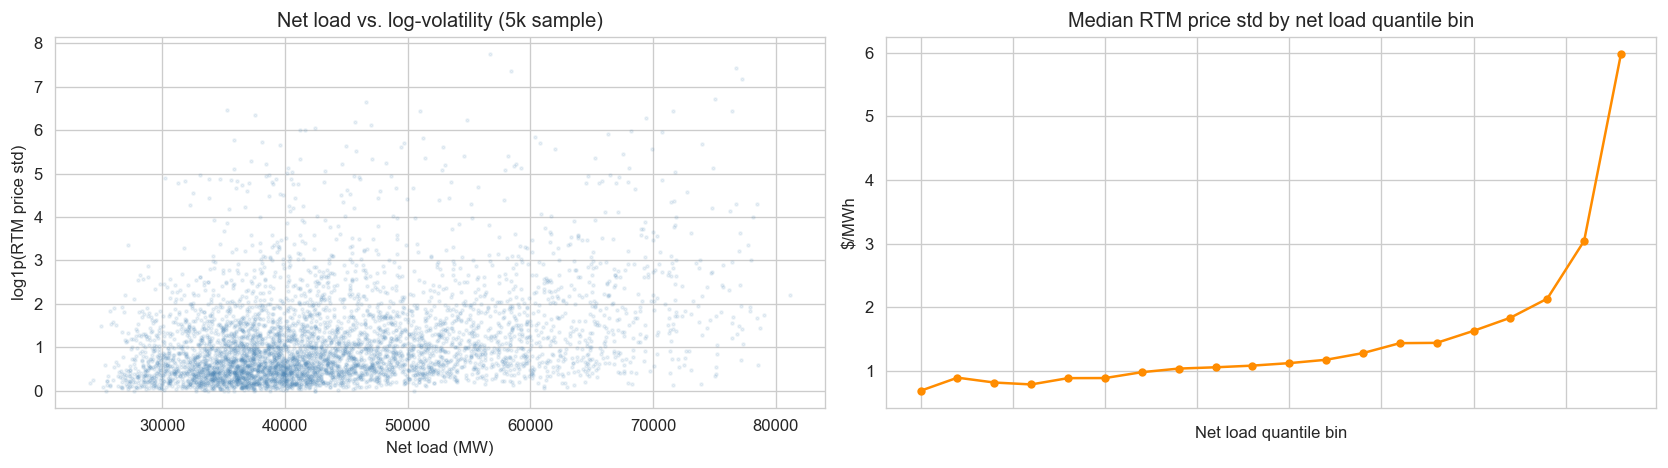

Correlation (net_load_mw vs log-vol): 0.322


In [11]:
# Net load vs. RTM volatility
_sub = df[['net_load_mw', 'rtm_price_std_hb_houston']].dropna()
_sub = _sub.copy()
_sub['nl_bin'] = pd.qcut(_sub['net_load_mw'], q=20)
_binned = _sub.groupby('nl_bin', observed=True)['rtm_price_std_hb_houston'].median()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

idx = _sub.sample(min(5000, len(_sub)), random_state=42).index
axes[0].scatter(_sub.loc[idx, 'net_load_mw'],
                np.log1p(_sub.loc[idx, 'rtm_price_std_hb_houston']),
                alpha=0.1, s=3, color='steelblue')
axes[0].set_xlabel('Net load (MW)'); axes[0].set_ylabel('log1p(RTM price std)')
axes[0].set_title('Net load vs. log-volatility (5k sample)')

_binned.plot(ax=axes[1], marker='o', ms=4, lw=1.5, color='darkorange')
axes[1].set_title('Median RTM price std by net load quantile bin')
axes[1].set_xlabel('Net load quantile bin'); axes[1].set_ylabel('$/MWh')
axes[1].set_xticklabels([])

plt.tight_layout()
plt.show()

corr = np.corrcoef(_sub['net_load_mw'], np.log1p(_sub['rtm_price_std_hb_houston']))[0,1]
print(f'Correlation (net_load_mw vs log-vol): {corr:.3f}')

### 3.2 Wind Forecast Error — proximate cause of RTM spikes

`wind_error_houston = gen_lz_south_houston - stwpf_lz_south_houston`  
Negative = wind underperformed forecast -> real-time must dispatch expensive backup.  
The relationship is asymmetric: underperformance hurts more than overperformance helps.

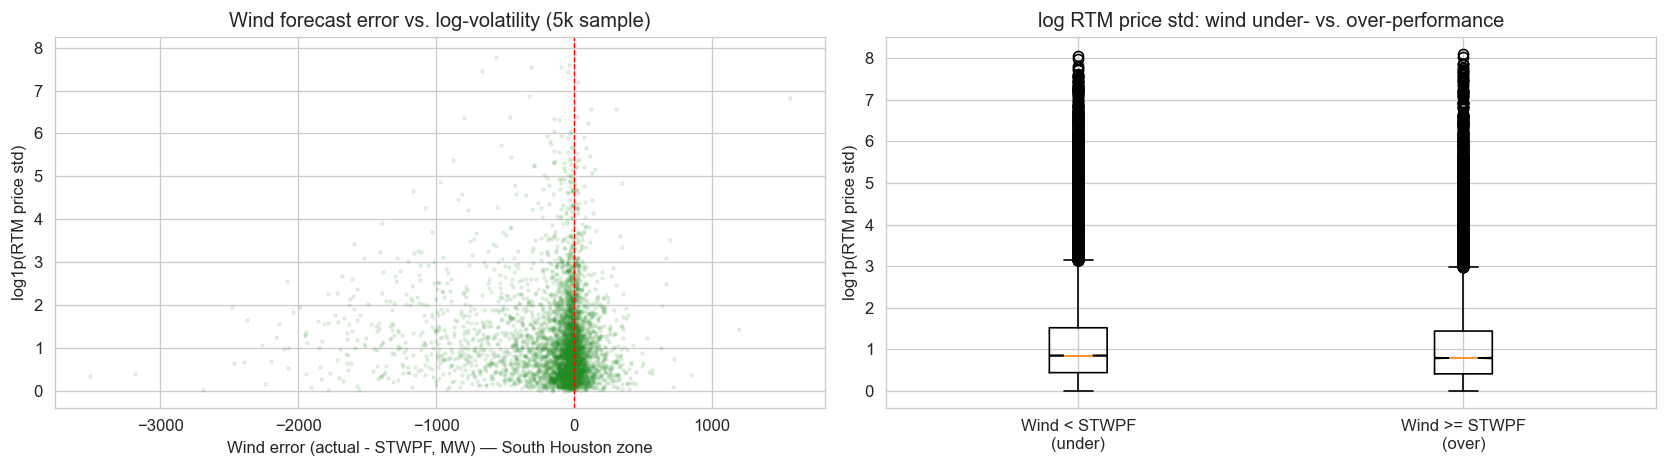

Median vol when wind < STWPF : 0.85 $/MWh  (n=50,522)
Median vol when wind >= STWPF: 0.79 $/MWh  (n=23,950)


In [12]:
# Wind error vs. RTM volatility
_sub2 = df[['wind_error_houston', 'rtm_price_std_hb_houston']].dropna()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))

idx2 = _sub2.sample(min(5000, len(_sub2)), random_state=42).index
axes[0].scatter(_sub2.loc[idx2, 'wind_error_houston'],
                np.log1p(_sub2.loc[idx2, 'rtm_price_std_hb_houston']),
                alpha=0.1, s=3, color='forestgreen')
axes[0].axvline(0, color='red', lw=0.8, linestyle='--')
axes[0].set_xlabel('Wind error (actual - STWPF, MW) — South Houston zone')
axes[0].set_ylabel('log1p(RTM price std)')
axes[0].set_title('Wind forecast error vs. log-volatility (5k sample)')

_neg = np.log1p(_sub2[_sub2['wind_error_houston'] < 0]['rtm_price_std_hb_houston'])
_pos = np.log1p(_sub2[_sub2['wind_error_houston'] >= 0]['rtm_price_std_hb_houston'])
axes[1].boxplot([_neg, _pos], tick_labels=['Wind < STWPF\n(under)', 'Wind >= STWPF\n(over)'], notch=True)
axes[1].set_title('log RTM price std: wind under- vs. over-performance')
axes[1].set_ylabel('log1p(RTM price std)')

plt.tight_layout()
plt.show()

print(f'Median vol when wind < STWPF : {_neg.median():.2f} $/MWh  (n={len(_neg):,})')
print(f'Median vol when wind >= STWPF: {_pos.median():.2f} $/MWh  (n={len(_pos):,})')

### 3.3 Forecast Revision Std — forward-looking uncertainty signal

`fc_coast_std_48h` / `wf_stwpf_lz_south_houston_std_48h` measure disagreement across
the D+1…D+7 forecast sequence.  High revision std = the market was uncertain about this
delivery hour days in advance — a genuine pre-delivery signal of volatility risk.

Both are Houston/Coast-specific: `fc_coast_std_48h` captures Coast zone load forecast
uncertainty; `wf_stwpf_lz_south_houston_std_48h` captures South Houston wind generation
forecast uncertainty.

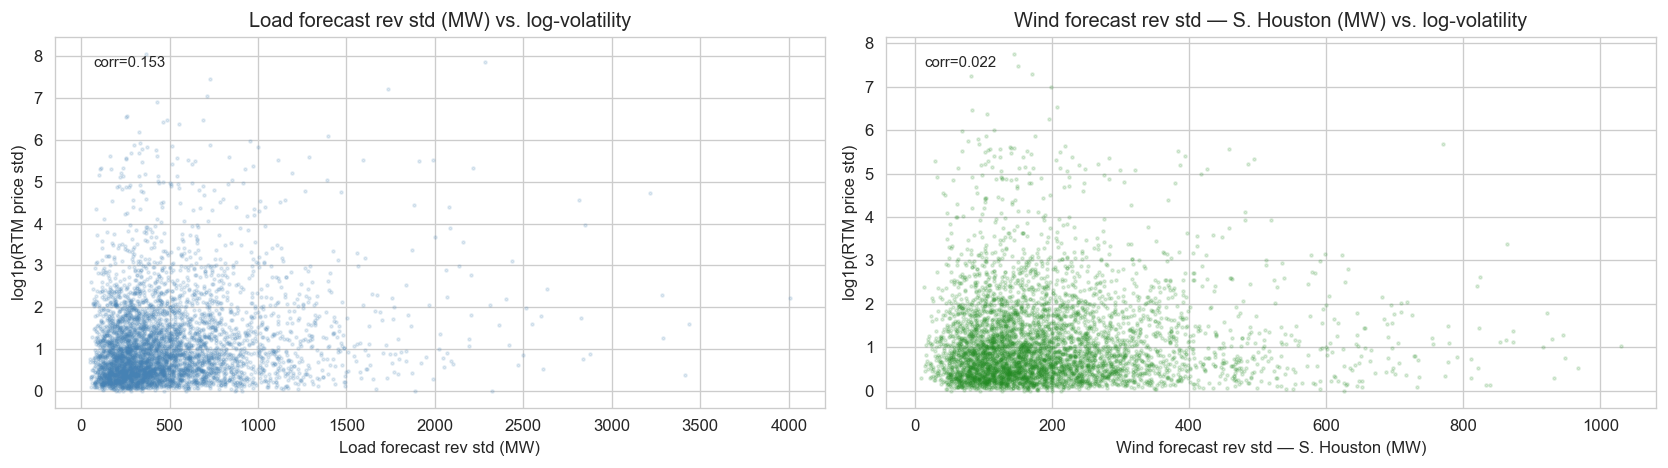

In [13]:
# Forecast revision std vs. RTM volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, fcol, label, color in [
    (axes[0], 'fc_system_total_std_48h',      'Load forecast rev std (MW)',   'steelblue'),
    (axes[1], 'wf_stwpf_lz_south_houston_std_48h', 'Wind forecast rev std — S. Houston (MW)', 'forestgreen'),
]:
    if fcol not in df.columns:
        ax.text(0.3, 0.5, f'{fcol}\nnot found', transform=ax.transAxes)
        continue
    _s = df[[fcol, 'rtm_price_std_hb_houston']].dropna()
    idx = _s.sample(min(5000, len(_s)), random_state=42).index
    ax.scatter(_s.loc[idx, fcol],
               np.log1p(_s.loc[idx, 'rtm_price_std_hb_houston']),
               alpha=0.15, s=3, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('log1p(RTM price std)')
    ax.set_title(f'{label} vs. log-volatility')
    corr = np.corrcoef(_s[fcol], np.log1p(_s['rtm_price_std_hb_houston']))[0,1]
    ax.text(0.05, 0.92, f'corr={corr:.3f}', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

### 3.4 DAM Price & DAM-RTM Spread

The day-ahead price reflects the market's prior expectation of scarcity. The DAM-RTM spread (`dam_price − rtm_mean`) measures how wrong that expectation was — a **level error**.

These two signals capture *different types of uncertainty*:
- **DAM price** → expected scarcity level going into delivery (available D-1)
- **DAM-RTM spread** (as a lagged feature) → how often the market mis-prices the mean; persistent mis-pricing signals a regime where the hour is harder to forecast

**Key finding:** The *signed* spread has a weaker correlation with log-volatility than DAM price alone. But `|DAM-RTM spread|` on a log scale reveals a substantially stronger signal — the **magnitude** of the mis-pricing (regardless of direction) predicts how volatile the hour turns out to be. This makes intuitive sense: large absolute errors in the day-ahead forecast indicate an uncertain, hard-to-predict hour whether the DAM over- or under-estimates the RTM mean.

For D+1 forecasting, use the **previous day's** DAM price and spread (lag-48); they are known at midnight D without leakage.

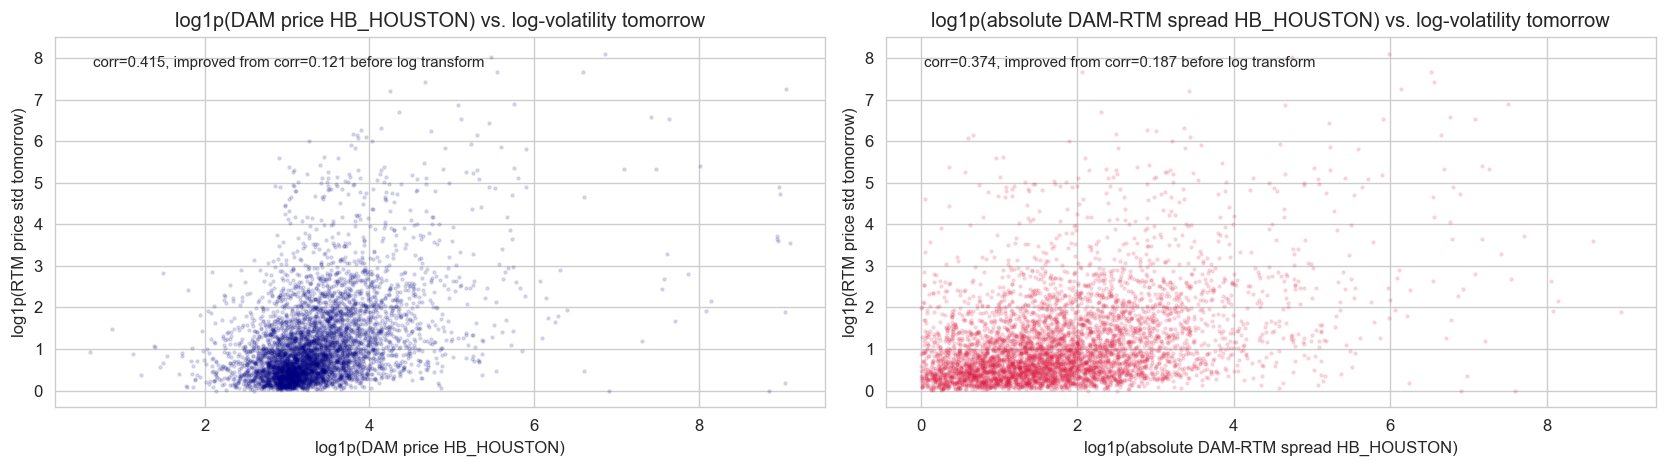

In [14]:
# DAM price and spread vs. RTM volatility
fig, axes = plt.subplots(1, 2, figsize=(14, 4))

for ax, col, label, color in [
    (axes[0], 'dam_price_houston', 'log1p(DAM price HB_HOUSTON)', 'navy'),
    (axes[1], 'abs_dam_rtm_spread_houston', 'log1p(absolute DAM-RTM spread HB_HOUSTON)', 'crimson')
]:
    if col not in df.columns:
        ax.text(0.3, 0.5, f'{col}\nnot found', transform=ax.transAxes)
        continue
    _s = df[[col, 'log_rtm_std_tomorrow']].dropna()
    idx = _s.sample(min(5000, len(_s)), random_state=42).index
    ax.scatter(np.log1p(_s.loc[idx, col]),
               _s.loc[idx, 'log_rtm_std_tomorrow'],
               alpha=0.12, s=3, color=color)
    ax.set_xlabel(label)
    ax.set_ylabel('log1p(RTM price std tomorrow)')
    ax.set_title(f'{label} vs. log-volatility tomorrow')
    corr = np.corrcoef(_s[col], _s['log_rtm_std_tomorrow'])[0,1]
    corr_log = np.corrcoef(np.log1p(_s[col]), _s['log_rtm_std_tomorrow'])[0,1]
    ax.text(0.05, 0.92, f'corr={corr_log:.3f}, improved from corr={corr:.3f} before log transform', transform=ax.transAxes, fontsize=9)

plt.tight_layout()
plt.show()

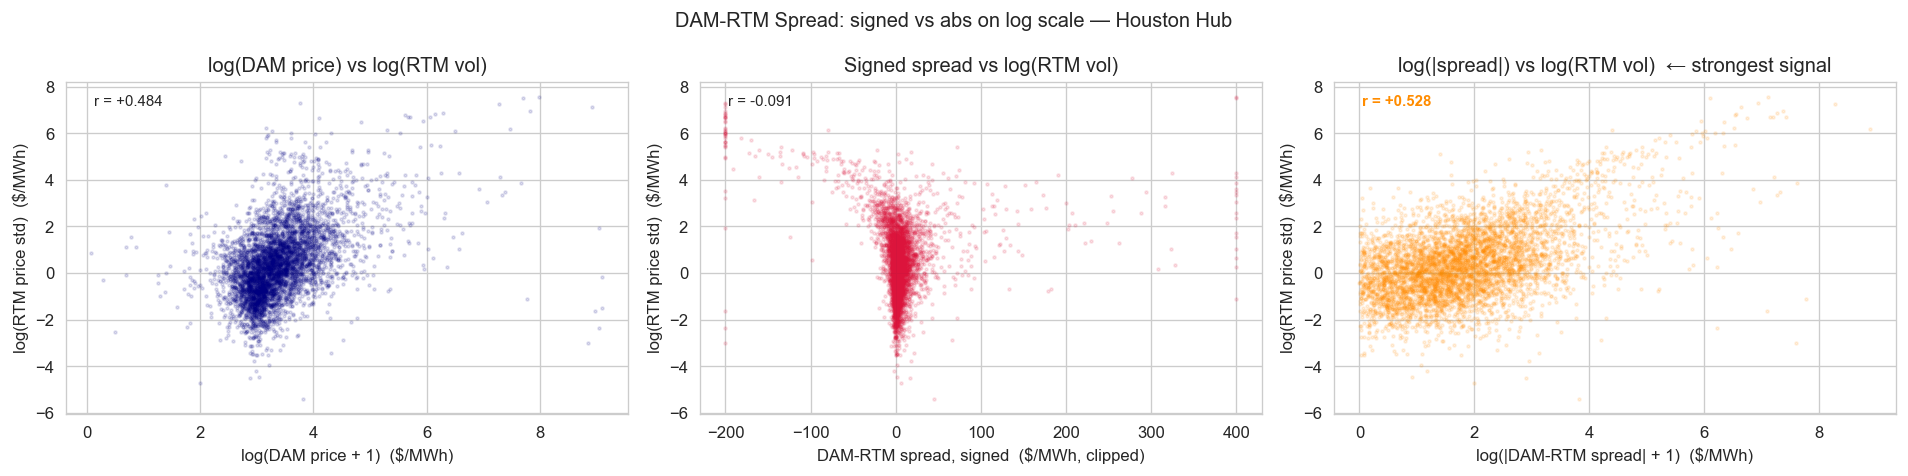

Correlation with log(RTM price std) — comparison across transformations:
Signal                                              r
-------------------------------------------------------
  |DAM-RTM spread| (log x)                    +0.528  ◀
  DAM price (log x)                           +0.484
  |DAM-RTM spread| (linear x)                 +0.261
  DAM price (linear x)                        +0.148
  DAM-RTM spread, signed (linear x)           -0.091


In [15]:
# Log-log analysis: abs(DAM-RTM spread) vs RTM volatility
# Key insight: magnitude of mis-pricing (abs spread) on a log scale reveals a
# stronger correlation with log-volatility than the signed spread or raw DAM price.

_s = df[['dam_price_houston', 'dam_rtm_spread_houston', 'rtm_price_std_hb_houston']].dropna()
_s = _s[_s['rtm_price_std_hb_houston'] > 0].copy()   # log requires > 0

_s['log_rtm_vol']    = np.log(_s['rtm_price_std_hb_houston'])
_s['log_dam']        = np.log1p(_s['dam_price_houston'].clip(lower=0))
_s['abs_spread']     = _s['dam_rtm_spread_houston'].abs()
_s['log_abs_spread'] = np.log1p(_s['abs_spread'])

# Correlation comparison
_corr_variants = {
    'DAM price (linear x)':              np.corrcoef(_s['dam_price_houston'],         _s['log_rtm_vol'])[0, 1],
    'DAM price (log x)':                 np.corrcoef(_s['log_dam'],                   _s['log_rtm_vol'])[0, 1],
    'DAM-RTM spread, signed (linear x)': np.corrcoef(_s['dam_rtm_spread_houston'],    _s['log_rtm_vol'])[0, 1],
    '|DAM-RTM spread| (linear x)':       np.corrcoef(_s['abs_spread'],               _s['log_rtm_vol'])[0, 1],
    '|DAM-RTM spread| (log x)':          np.corrcoef(_s['log_abs_spread'],            _s['log_rtm_vol'])[0, 1],
}

idx = _s.sample(min(5000, len(_s)), random_state=42).index

fig, axes = plt.subplots(1, 3, figsize=(16, 4))

# Panel 1: log(DAM price) vs log(RTM vol)
axes[0].scatter(_s.loc[idx, 'log_dam'], _s.loc[idx, 'log_rtm_vol'],
                alpha=0.12, s=3, color='navy')
axes[0].set_xlabel('log(DAM price + 1)  ($/MWh)')
axes[0].set_ylabel('log(RTM price std)  ($/MWh)')
axes[0].set_title('log(DAM price) vs log(RTM vol)')
axes[0].text(0.05, 0.93, f"r = {_corr_variants['DAM price (log x)']:+.3f}",
             transform=axes[0].transAxes, fontsize=9)

# Panel 2: signed spread (linear) vs log(RTM vol)
axes[1].scatter(_s.loc[idx, 'dam_rtm_spread_houston'].clip(-200, 400),
                _s.loc[idx, 'log_rtm_vol'],
                alpha=0.12, s=3, color='crimson')
axes[1].set_xlabel('DAM-RTM spread, signed  ($/MWh, clipped)')
axes[1].set_ylabel('log(RTM price std)  ($/MWh)')
axes[1].set_title('Signed spread vs log(RTM vol)')
axes[1].text(0.05, 0.93, f"r = {_corr_variants['DAM-RTM spread, signed (linear x)']:+.3f}",
             transform=axes[1].transAxes, fontsize=9)

# Panel 3: log(|spread|) vs log(RTM vol)  ← key finding
axes[2].scatter(_s.loc[idx, 'log_abs_spread'], _s.loc[idx, 'log_rtm_vol'],
                alpha=0.12, s=3, color='darkorange')
axes[2].set_xlabel('log(|DAM-RTM spread| + 1)  ($/MWh)')
axes[2].set_ylabel('log(RTM price std)  ($/MWh)')
axes[2].set_title('log(|spread|) vs log(RTM vol)  ← strongest signal')
axes[2].text(0.05, 0.93, f"r = {_corr_variants['|DAM-RTM spread| (log x)']:+.3f}",
             transform=axes[2].transAxes, fontsize=9, color='darkorange',
             fontweight='bold')

plt.suptitle('DAM-RTM Spread: signed vs abs on log scale — Houston Hub', fontsize=12)
plt.tight_layout()
_fig_dir_dam = Path('figures/eda')
_fig_dir_dam.mkdir(parents=True, exist_ok=True)
plt.savefig(_fig_dir_dam / 'dam_rtm_spread_loglog.png', dpi=150, bbox_inches='tight')
plt.show()

print("Correlation with log(RTM price std) — comparison across transformations:")
print(f"{'Signal':<45} {'r':>7}")
print("-" * 55)
for label, r in sorted(_corr_variants.items(), key=lambda x: abs(x[1]), reverse=True):
    marker = "  ◀" if label == '|DAM-RTM spread| (log x)' else ""
    print(f"  {label:<43} {r:+.3f}{marker}")

It seems there is minimal need for absolute DAM-RTM spread, since the relationship with signed spread is mildly stronger.

### 3.5 Ancillary Service Prices — leading indicators of reserve tightness

When REGUP and RRS prices spike in the DAM, the system operator expected a tight reserve margin
the next day — a leading indicator of RTM volatility.

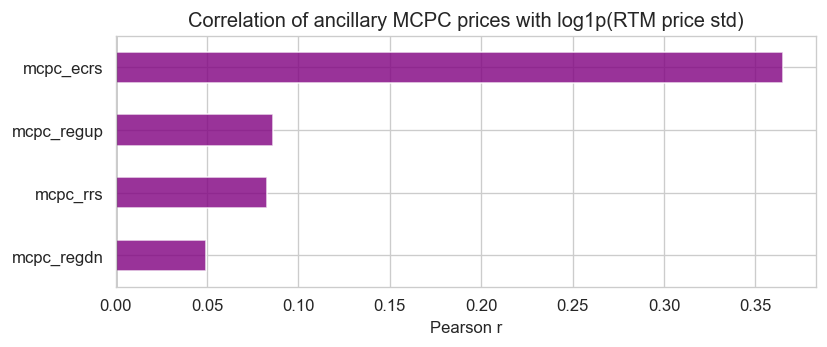

In [16]:
# Ancillary prices vs. RTM volatility
_anc_cols = [c for c in ['mcpc_rrs','mcpc_regup','mcpc_ecrs','mcpc_regdn','mcpc_nsrs']
             if c in df.columns]

corrs = {}
for c in _anc_cols:
    _s = df[[c, 'rtm_price_std_hb_houston']].dropna()
    corrs[c] = np.corrcoef(_s[c], np.log1p(_s['rtm_price_std_hb_houston']))[0,1]

fig, ax = plt.subplots(figsize=(7, 3))
pd.Series(corrs).sort_values().plot(kind='barh', ax=ax, color='purple', alpha=0.8)
ax.axvline(0, color='black', lw=0.8)
ax.set_title('Correlation of ancillary MCPC prices with log1p(RTM price std)')
ax.set_xlabel('Pearson r')
plt.tight_layout()
plt.show()

### 3.6 Feature Candidates

Selected key features available at the **midnight CST cutoff** (00:00 CST of delivery day) and their expected signal direction. This is not an exhaustive list — the full feature set includes all features here plus engineered features (`fc_net_load`, `dam_rtm_spread`, lags, `outage_fraction`) and additional ancillary prices. Note: `mcpc_ecrs` is excluded from all models despite being leakage-safe — it only launched June 2021, leaving insufficient pre-Uri history.

| Feature | Source | Signal direction |
|---|---|---|
| `mcpc_regup`, `mcpc_rrs` | NP4-188 ancillary | Positive — reserve scarcity → volatility |
| `dam_price_houston` | NP4-190 DAM | Positive — high DAM → tight supply |
| `dam_rtm_spread` (lagged) | NP4-190 + NP6-905 | Positive — level mis-pricing co-occurs with high-volatility regimes |
| `fc_coast_std_48h` | NP3-565 forecast revision | Positive — uncertain load forecast → uncertain delivery |
| `total_resource_mw` | NP3-233 outage | Positive — more outages → tighter margin |
| `wf_stwpf_lz_south_houston` | NP4-732 wind forecast | Negative — more wind → lower net load |
| `temp_f_houston_avg` | Weather | Positive in summer — heat drives AC load → scarcity |
| `garch_cond_vol` | Derived (GARCH) | Positive — volatility clusters; yesterday's regime predicts today's |

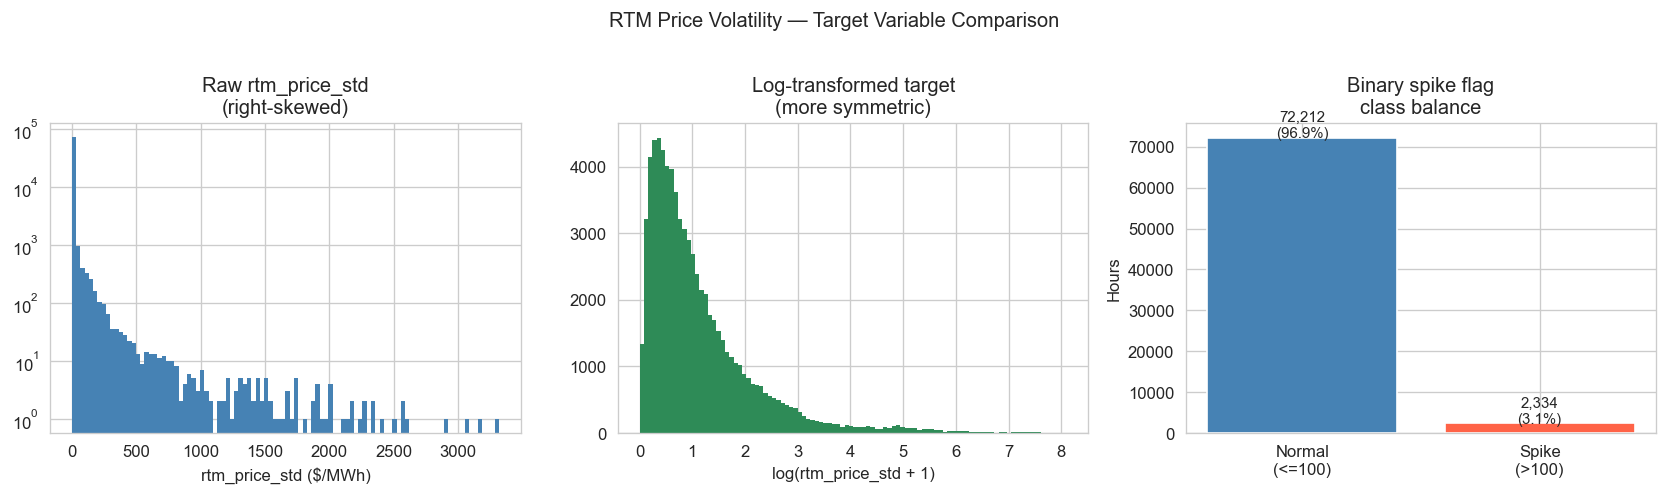

rtm_price_std stats:
count    74546.00
mean        10.33
std         74.49
min          0.00
25%          0.53
50%          1.29
75%          3.43
max       3319.99
Name: rtm_price_std, dtype: float64

log(rtm_price_std+1) stats:
count    74546.000
mean         1.134
std          1.040
min          0.000
25%          0.426
50%          0.828
75%          1.489
max          8.108
Name: rtm_price_std, dtype: float64

Spike rate: 3.13% of hours


In [17]:
# --- Target variable distribution analysis ---
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from pathlib import Path

_PROC = Path('data/processed/ercot')
rtm = pd.read_parquet(_PROC / 'np6_905_rtm_hourly_houston.parquet')[['ts_cst', 'rtm_price_std', 'rtm_price_mean']]
rtm = rtm.dropna(subset=['rtm_price_std'])

log_std = np.log1p(rtm['rtm_price_std'])
spike_flag = (rtm['rtm_price_mean'] > 100).astype(int)

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

# 1. Raw rtm_price_std distribution
axes[0].hist(rtm['rtm_price_std'], bins=100, color='steelblue', edgecolor='none')
axes[0].set_xlabel('rtm_price_std ($/MWh)')
axes[0].set_title('Raw rtm_price_std\n(right-skewed)')
axes[0].set_yscale('log')

# 2. Log-transformed distribution
axes[1].hist(log_std, bins=100, color='seagreen', edgecolor='none')
axes[1].set_xlabel('log(rtm_price_std + 1)')
axes[1].set_title('Log-transformed target\n(more symmetric)')

# 3. Spike flag class balance
spike_counts = spike_flag.value_counts().sort_index()
axes[2].bar(['Normal\n(<=100)', 'Spike\n(>100)'], spike_counts.values, color=['steelblue', 'tomato'])
axes[2].set_title('Binary spike flag\nclass balance')
axes[2].set_ylabel('Hours')
for i, v in enumerate(spike_counts.values):
    axes[2].text(i, v + 50, f'{v:,}\n({v/len(rtm)*100:.1f}%)', ha='center', fontsize=9)

plt.suptitle('RTM Price Volatility — Target Variable Comparison', fontsize=12, y=1.02)
plt.tight_layout()
plt.show()

print(f"rtm_price_std stats:")
print(rtm['rtm_price_std'].describe().round(2))
print(f"\nlog(rtm_price_std+1) stats:")
print(log_std.describe().round(3))
print(f"\nSpike rate: {spike_flag.mean()*100:.2f}% of hours")

Pearson correlation with log(rtm_price_std+1):
mcpc_ecrs                 0.365
fc_system_total           0.339
dam_price_houston         0.169
system_lambda             0.166
rtm_mean_lag24            0.109
mcpc_nspin                0.107
wgrpp_lz_south_houston    0.093
mcpc_regup                0.086
mcpc_rrs                  0.083
wind_error_houston       -0.083
total_resource_mw         0.067
mcpc_regdn                0.050


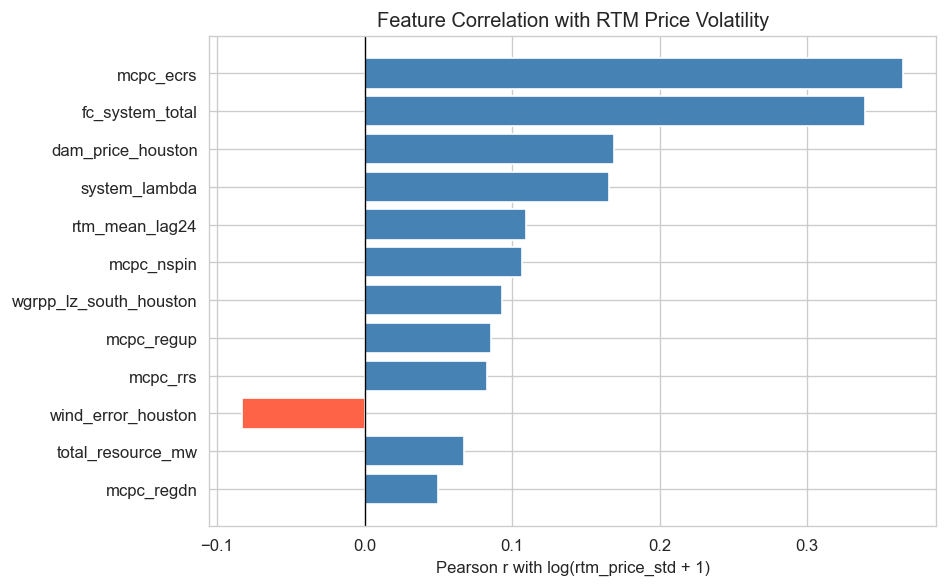

Plot saved.


In [18]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

_PROC = Path('data/processed/ercot')

# Load target
rtm = pd.read_parquet(_PROC / 'np6_905_rtm_hourly_houston.parquet')[['ts_cst', 'rtm_price_std', 'rtm_price_mean']]
rtm['log_rtm_std'] = np.log1p(rtm['rtm_price_std'])

# Load features
anc_regup = pd.read_parquet(_PROC / 'np4_188_mcpc_regup.parquet')[['ts_cst', 'mcpc_regup']]
anc_rrs   = pd.read_parquet(_PROC / 'np4_188_mcpc_rrs.parquet')[['ts_cst', 'mcpc_rrs']]
anc_ecrs  = pd.read_parquet(_PROC / 'np4_188_mcpc_ecrs.parquet')[['ts_cst', 'mcpc_ecrs']]
anc_nspin = pd.read_parquet(_PROC / 'np4_188_mcpc_nspin.parquet')[['ts_cst', 'mcpc_nspin']]
anc_regdn = pd.read_parquet(_PROC / 'np4_188_mcpc_regdn.parquet')[['ts_cst', 'mcpc_regdn']]
dam  = pd.read_parquet(_PROC / 'np4_190_dam_houston.parquet')[['ts_cst', 'dam_price_houston']]
lam  = pd.read_parquet(_PROC / 'np4_523_system_lambda.parquet')[['ts_cst', 'system_lambda']]
wind = pd.read_parquet(_PROC / 'np4_732_wind_houston.parquet')[['ts_cst', 'wind_error_houston', 'wgrpp_lz_south_houston']]
out  = pd.read_parquet(_PROC / 'np3_233_outage_total.parquet')[['ts_cst', 'total_resource_mw']]
fc   = pd.read_parquet(_PROC / 'np3_565_forecast1.parquet')[['ts_cst', 'fc_system_total']]

df_corr = rtm.copy()
for d in [anc_regup, anc_rrs, anc_ecrs, anc_nspin, anc_regdn, dam, lam, wind, out, fc]:
    df_corr = df_corr.merge(d, on='ts_cst', how='left')

df_corr = df_corr.sort_values('ts_cst').reset_index(drop=True)
df_corr['rtm_mean_lag24'] = df_corr['rtm_price_mean'].shift(24)

feat_cols = ['mcpc_regup', 'mcpc_rrs', 'mcpc_ecrs', 'mcpc_nspin', 'mcpc_regdn',
             'dam_price_houston', 'system_lambda', 'wind_error_houston',
             'wgrpp_lz_south_houston', 'total_resource_mw', 'fc_system_total', 'rtm_mean_lag24']

corr = df_corr[feat_cols + ['log_rtm_std']].corr()['log_rtm_std'].drop('log_rtm_std').sort_values(key=abs, ascending=False)
print("Pearson correlation with log(rtm_price_std+1):")
print(corr.round(3).to_string())

fig, ax = plt.subplots(figsize=(8, 5))
colors = ['steelblue' if v > 0 else 'tomato' for v in corr.values]
ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
ax.axvline(0, color='black', linewidth=0.8)
ax.set_xlabel('Pearson r with log(rtm_price_std + 1)')
ax.set_title('Feature Correlation with RTM Price Volatility')
plt.tight_layout()
plt.savefig('figures/eda/volatility_feature_correlation.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

### Non-Linear Effects: Wind Error × Load Interaction

Pearson correlations only capture linear relationships. We test three non-linear hypotheses by computing correlations of composite variables within load-stratified bins:

1. **Wind error only matters when load is high** — a 1 GW wind miss is benign at low demand but catastrophic near peak
2. **ECRS price has a threshold effect** — volatility jumps sharply once ECRS crosses a scarcity price level
3. **DAM price × outage interaction** — high outages amplify the effect of high DAM prices

**Approach:** bin `fc_system_total` into load quartiles, then compute Pearson r of each composite feature vs `log_rtm_std` within each bin. This tests whether *direction or strength of the linear relationship* varies by regime — it does not constitute a full non-linear test.

**Note on scope:** a proper non-linear assessment would use mutual information, partial dependence plots (from the trained XGBoost model), or SHAP interaction values. The analysis here is exploratory — the XGBoost tree structure captures these non-linearities implicitly during model training.

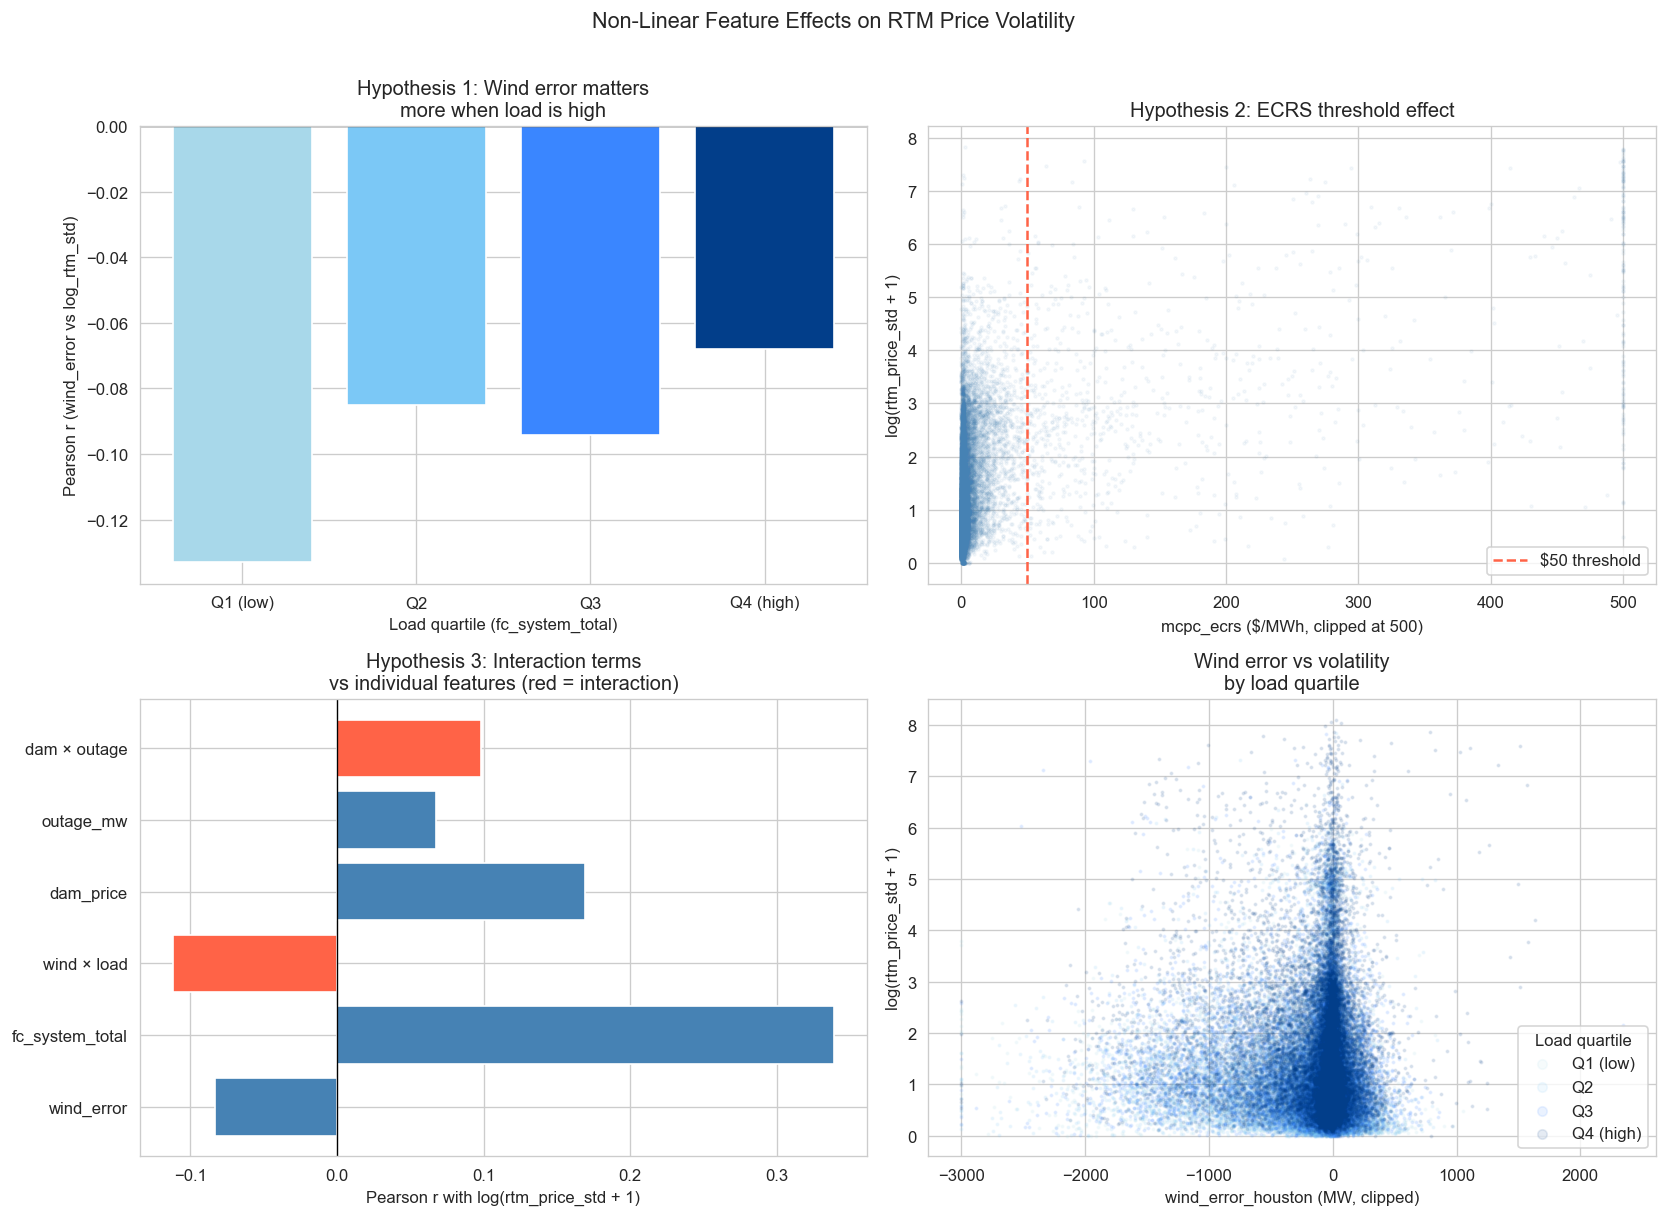

Plot saved.

Interaction term correlations with log(rtm_price_std+1):
  wind_error             r = -0.083
  fc_system_total        r = 0.339
  wind × load            r = -0.112
  dam_price              r = 0.169
  outage_mw              r = 0.067
  dam × outage           r = 0.098

Wind error correlation by load quartile:
load_quartile
Q1 (low)    -0.133
Q2          -0.085
Q3          -0.094
Q4 (high)   -0.068


In [19]:
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from pathlib import Path

_PROC = Path('data/processed/ercot')

# Load data
rtm  = pd.read_parquet(_PROC / 'np6_905_rtm_hourly_houston.parquet')[['ts_cst', 'rtm_price_std', 'rtm_price_mean']]
wind = pd.read_parquet(_PROC / 'np4_732_wind_houston.parquet')[['ts_cst', 'wind_error_houston', 'wgrpp_lz_south_houston']]
fc   = pd.read_parquet(_PROC / 'np3_565_forecast1.parquet')[['ts_cst', 'fc_system_total']]
out  = pd.read_parquet(_PROC / 'np3_233_outage_total.parquet')[['ts_cst', 'total_resource_mw']]
dam  = pd.read_parquet(_PROC / 'np4_190_dam_houston.parquet')[['ts_cst', 'dam_price_houston']]
ecrs = pd.read_parquet(_PROC / 'np4_188_mcpc_ecrs.parquet')[['ts_cst', 'mcpc_ecrs']]

df_nl = rtm.copy()
for d in [wind, fc, out, dam, ecrs]:
    df_nl = df_nl.merge(d, on='ts_cst', how='left')

df_nl['log_rtm_std'] = np.log1p(df_nl['rtm_price_std'])
df_nl = df_nl.dropna(subset=['log_rtm_std', 'fc_system_total', 'wind_error_houston'])

# Interaction terms
df_nl['wind_x_load'] = df_nl['wind_error_houston'] * df_nl['fc_system_total']
df_nl['dam_x_outage'] = df_nl['dam_price_houston'] * df_nl['total_resource_mw']
df_nl['load_quartile'] = pd.qcut(df_nl['fc_system_total'], q=4, labels=['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'])

# --- Plot ---
fig, axes = plt.subplots(2, 2, figsize=(14, 10))

# 1. Wind error correlation with log_rtm_std by load quartile
quartile_corrs = df_nl.groupby('load_quartile', observed=True).apply(
    lambda g: g['wind_error_houston'].corr(g['log_rtm_std'])
)
axes[0, 0].bar(quartile_corrs.index, quartile_corrs.values, color=['#a8d8ea', '#7bc8f6', '#3a86ff', '#023e8a'])
axes[0, 0].axhline(0, color='black', linewidth=0.8)
axes[0, 0].set_xlabel('Load quartile (fc_system_total)')
axes[0, 0].set_ylabel('Pearson r (wind_error vs log_rtm_std)')
axes[0, 0].set_title('Hypothesis 1: Wind error matters\nmore when load is high')

# 2. ECRS threshold effect — scatter with threshold line
ecrs_data = df_nl.dropna(subset=['mcpc_ecrs'])
axes[0, 1].scatter(ecrs_data['mcpc_ecrs'].clip(upper=500), ecrs_data['log_rtm_std'],
                   alpha=0.05, s=3, color='steelblue')
axes[0, 1].axvline(50, color='tomato', linewidth=1.5, linestyle='--', label='$50 threshold')
axes[0, 1].set_xlabel('mcpc_ecrs (\\$/MWh, clipped at 500)')
axes[0, 1].set_ylabel('log(rtm_price_std + 1)')
axes[0, 1].set_title('Hypothesis 2: ECRS threshold effect')
axes[0, 1].legend()

# 3. Interaction term correlations vs individual
base_corrs = {
    'wind_error': df_nl['wind_error_houston'].corr(df_nl['log_rtm_std']),
    'fc_system_total': df_nl['fc_system_total'].corr(df_nl['log_rtm_std']),
    'wind × load': df_nl['wind_x_load'].corr(df_nl['log_rtm_std']),
    'dam_price': df_nl['dam_price_houston'].corr(df_nl['log_rtm_std']),
    'outage_mw': df_nl['total_resource_mw'].corr(df_nl['log_rtm_std']),
    'dam × outage': df_nl['dam_x_outage'].corr(df_nl['log_rtm_std']),
}
colors = ['tomato' if '×' in k else 'steelblue' for k in base_corrs]
axes[1, 0].barh(list(base_corrs.keys()), list(base_corrs.values()), color=colors)
axes[1, 0].axvline(0, color='black', linewidth=0.8)
axes[1, 0].set_xlabel('Pearson r with log(rtm_price_std + 1)')
axes[1, 0].set_title('Hypothesis 3: Interaction terms\nvs individual features (red = interaction)')

# 4. Wind error vs log_rtm_std colored by load quartile
for q, color in zip(['Q1 (low)', 'Q2', 'Q3', 'Q4 (high)'], ['#a8d8ea', '#7bc8f6', '#3a86ff', '#023e8a']):
    mask = df_nl['load_quartile'] == q
    axes[1, 1].scatter(df_nl.loc[mask, 'wind_error_houston'].clip(-3000, 3000),
                       df_nl.loc[mask, 'log_rtm_std'],
                       alpha=0.1, s=2, color=color, label=q.replace('\n', ' '))
axes[1, 1].set_xlabel('wind_error_houston (MW, clipped)')
axes[1, 1].set_ylabel('log(rtm_price_std + 1)')
axes[1, 1].set_title('Wind error vs volatility\nby load quartile')
axes[1, 1].legend(title='Load quartile', markerscale=4)

plt.suptitle('Non-Linear Feature Effects on RTM Price Volatility', fontsize=13, y=1.01)
plt.tight_layout()
plt.savefig('figures/eda/volatility_nonlinear_effects.png', dpi=150, bbox_inches='tight')
plt.show()
print("Plot saved.")

# Print interaction term correlations
print("\nInteraction term correlations with log(rtm_price_std+1):")
for k, v in base_corrs.items():
    print(f"  {k:<22} r = {v:.3f}")

print("\nWind error correlation by load quartile:")
print(quartile_corrs.round(3).to_string())

### Non-Linear Effects — Conclusions

**Hypothesis 1 — Wind error × load**: NOT confirmed. Wind error is weakly negative at low load (r=−0.13) but near zero at peak. No load-quartile amplification. Drop `wind × load` interaction.

**Hypothesis 2 — ECRS threshold**: CONFIRMED in EDA — volatility fans out sharply above ~\$50 ECRS. However, ECRS was **excluded from all models** because it only began in 2021-06, providing insufficient history for pre-Uri training windows.

**Hypothesis 3 — DAM × outage interaction**: NOT confirmed. Interaction term (r=0.094) weaker than DAM alone (r=0.165). Drop.

---

### Final Feature Set for Modeling

| Feature | Transform | Source |
|---|---|---|
| `fc_system_total` | as-is | np3_565 |
| `dam_price_houston` | as-is | np4_190 |
| `system_lambda` | as-is | np4_523 |
| `mcpc_regup`, `mcpc_rrs`, `mcpc_nspin` | as-is | np4_188 |
| `total_resource_mw` (outages) | as-is | np3_233 |
| `rtm_std_lag24` | as-is | np6_905 |
| `wgrpp_lz_south_houston` | as-is | np4_732 |
| `wind_error_houston` | tentative — weak signal | np4_732 |
| `temp_f_houston_avg`, `humidity_pct_houston_avg`, `wind_gust_mph_houston_avg`, `precip_in_houston_avg` | as-is (hourly avg) | weather_hourly |

**Target**: `log(rtm_price_std + 1)` (regression) · `rtm_price_mean > $100/MWh` (binary, secondary)

**Train window**: 2017-07 → 2024-12 · **Test**: 2025 · **Hold-out**: 2026

### 3.7 Weather: Houston vs Texas-Wide Correlation

We have two weather aggregates for each variable:
- **Houston avg** — stations in the Houston metro area (directly relevant to Houston Hub)
- **Texas avg** — stations statewide (captures West Texas wind/load, DFW demand, etc.)

Before using both in the model, we check whether they are redundant (high correlation → keep only Houston) or complementary (low correlation → both add signal).

**Threshold: r > 0.80 → drop Texas aggregate, keep Houston only.** Variables at or below this threshold retain both aggregates as they still carry meaningful regional signal beyond what Houston stations capture.

After applying this threshold, **precipitation (r ≈ 0.662) is the only statewide variable we retain** — its Texas aggregate still diverges enough from Houston to be informative. However, we will soon see that neither Texas nor Houston precipitation data has a strong relationship with price spread.

Variable                 r(Houston, Texas)  Decision
──────────────────────────────────────────────────────────────
Temperature (°F)                    0.9636  Houston only (redundant)
Humidity (%)                        0.8337  Houston only (redundant)
Precipitation (in)                  0.6624  Keep both (regional signal)
Wind Gust (mph)                     0.8063  Houston only (redundant)
Pressure (hPa)                      0.9387  Houston only (redundant)

Threshold: r > 0.80 → drop Texas aggregate


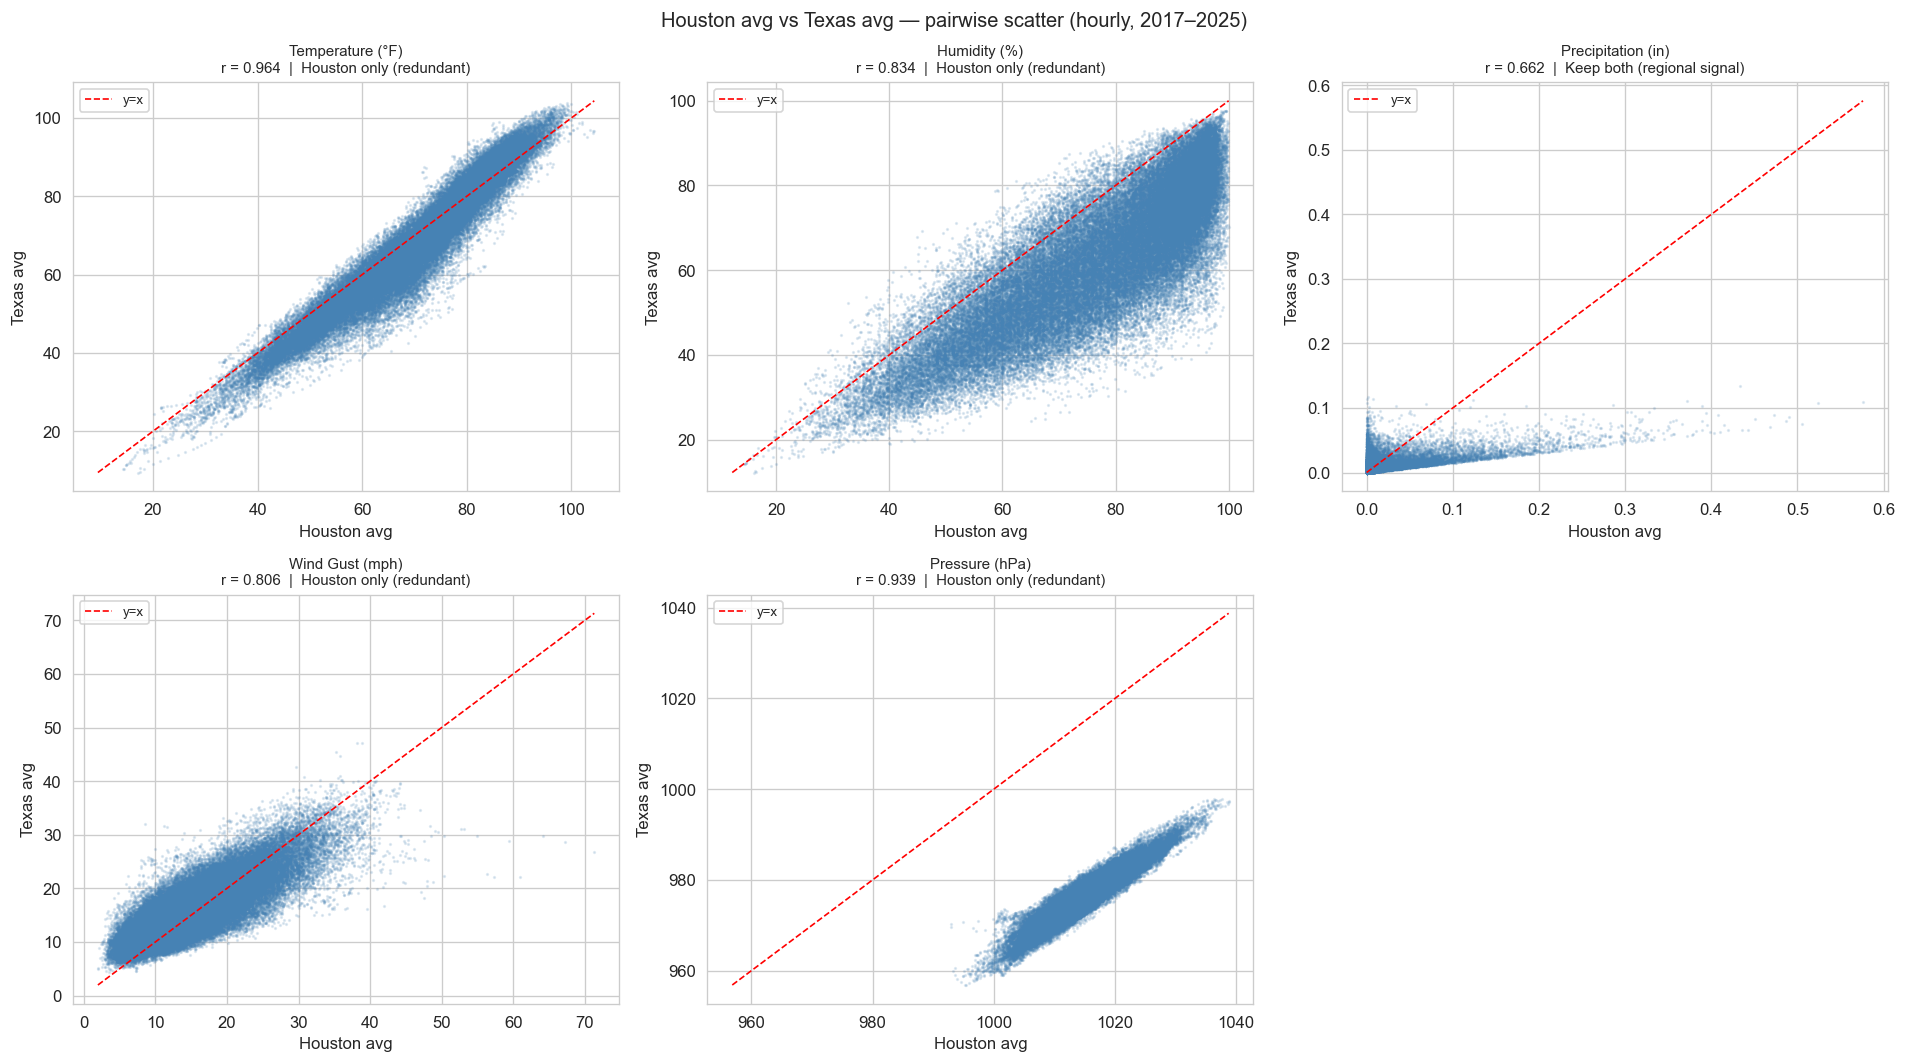

In [20]:
# ── 3.7 Houston vs Texas weather correlation analysis ─────────────────────────
_wx = pd.read_parquet(PROCESSED_ROOT / 'weather_hourly.parquet')
_wx['ts_cst'] = pd.to_datetime(_wx['ts_cst'])

_vars = ['temp_f', 'humidity_pct', 'precip_in', 'wind_gust_mph', 'pressure_hpa']
_var_labels = {
    'temp_f':         'Temperature (°F)',
    'humidity_pct':   'Humidity (%)',
    'precip_in':      'Precipitation (in)',
    'wind_gust_mph':  'Wind Gust (mph)',
    'pressure_hpa':   'Pressure (hPa)',
}

# ── Correlation table ──────────────────────────────────────────────────────────
print(f"{'Variable':<22}  {'r(Houston, Texas)':>18}  {'Decision'}")
print('─' * 62)
decisions = {}
for v in _vars:
    h = _wx[f'{v}_houston_avg'].dropna()
    t = _wx[f'{v}_texas_avg'].dropna()
    idx = h.index.intersection(t.index)
    r = h.loc[idx].corr(t.loc[idx])
    if r > 0.80:
        dec = 'Houston only (redundant)'
    else:
        dec = 'Keep both (regional signal)'
    decisions[v] = (r, dec)
    print(f"{_var_labels[v]:<22}  {r:>18.4f}  {dec}")

print()
print("Threshold: r > 0.80 → drop Texas aggregate")

# ── Scatter plots: Houston vs Texas for each variable ─────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, v in zip(axes, _vars):
    h = _wx[f'{v}_houston_avg']
    t = _wx[f'{v}_texas_avg']
    r, dec = decisions[v]
    ax.scatter(h, t, s=1, alpha=0.15, color='steelblue', rasterized=True)
    # diagonal reference line
    lo = min(h.min(), t.min()); hi = max(h.max(), t.max())
    ax.plot([lo, hi], [lo, hi], 'r--', lw=1, label='y=x')
    ax.set_xlabel(f'Houston avg')
    ax.set_ylabel(f'Texas avg')
    ax.set_title(f'{_var_labels[v]}\nr = {r:.3f}  |  {dec}', fontsize=9)
    ax.legend(fontsize=8)

axes[-1].set_visible(False)  # hide unused 6th panel
fig.suptitle('Houston avg vs Texas avg — pairwise scatter (hourly, 2017–2025)', fontsize=12)
plt.tight_layout()
plt.savefig('figures/eda/weather_houston_texas_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

As seen below, however, **neither Houston nor Texas precipitation data is particularly correlated with price spread**.

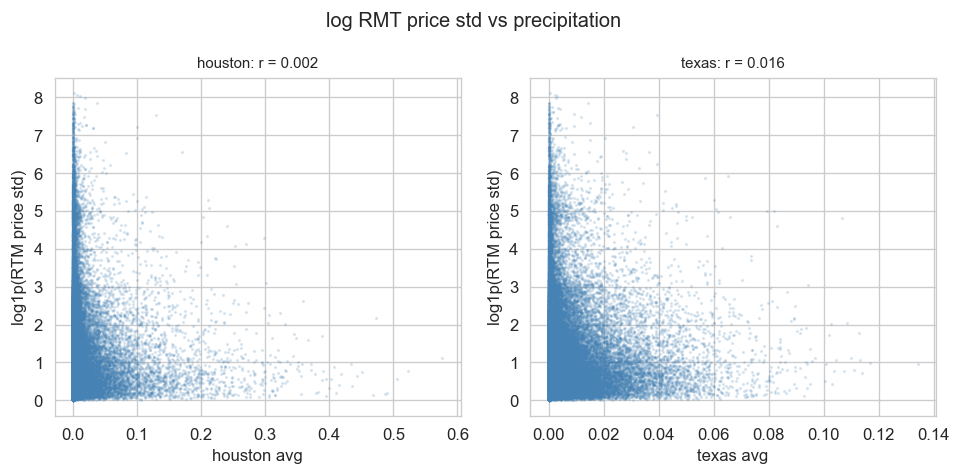

In [21]:
fig, axes = plt.subplots(1, 2, figsize=(8, 4))
axes = axes.flatten()

for i, loc in enumerate(('houston', 'texas')):
    precip = _wx[f'precip_in_{loc}_avg']
    log_rtm = np.log1p(df['rtm_price_std_hb_houston'].dropna())
    idx = precip.index.intersection(log_rtm.index)
    r = precip.loc[idx].corr(log_rtm.loc[idx])
    axes[i].scatter(precip.loc[idx][:-25], log_rtm.loc[idx][25:], s=1, alpha=0.15, color='steelblue', rasterized=True)
    axes[i].set_xlabel(f'{loc} avg')
    axes[i].set_ylabel('log1p(RTM price std)')
    axes[i].set_title(f'{loc}: r = {r:.3f}', fontsize=9)

fig.suptitle('log RMT price std vs precipitation', fontsize=12)
plt.tight_layout()
plt.savefig('figures/eda/precipitation_log_rtm_scatter.png', dpi=120, bbox_inches='tight')
plt.show()

### 3.8 Calendar Effects — Day-of-Week and Hour-of-Day

Day-of-week and hour-of-day are included as features (`dow`, `hour`). We verify their relationship with RTM price volatility using a heatmap of mean `log_rtm_std` by hour × day-of-week. Strong patterns justify including these calendar features in the model.

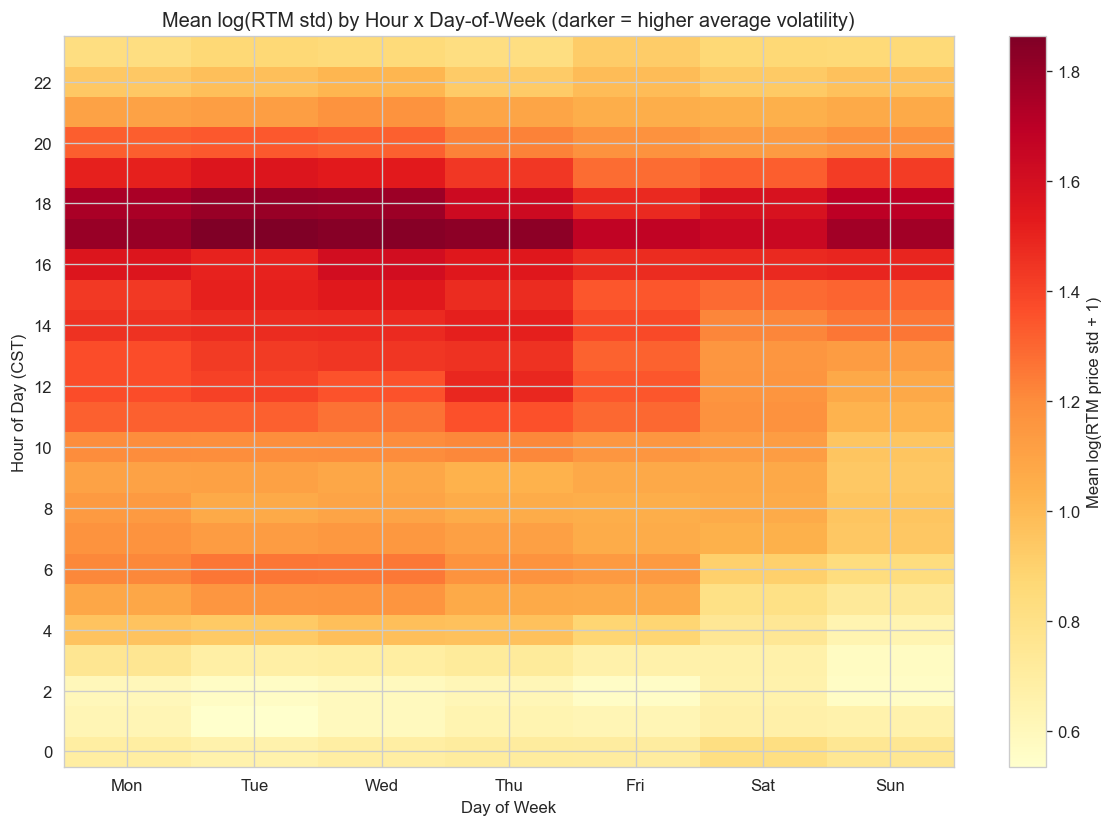

Peak volatility hour x day combinations:
  Hour 17:00 Tue: mean log_std = 1.863
  Hour 17:00 Wed: mean log_std = 1.838
  Hour 17:00 Thu: mean log_std = 1.826
  Hour 17:00 Mon: mean log_std = 1.795
  Hour 18:00 Tue: mean log_std = 1.794


In [22]:
# -- S3.8 Calendar Effects: Hour x Day-of-Week Volatility Heatmap
# Data: df (ercot_combined, loaded in S1)

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

# Build pivot: mean log(rtm_price_std+1) by hour and day-of-week
_ec = df.copy()
_ec["log_rtm_std"] = np.log1p(_ec["rtm_price_std_hb_houston"].clip(lower=0))
_ec["hour"] = pd.to_datetime(_ec["ts_cst"]).dt.hour if "ts_cst" in _ec.columns else _ec.index.hour
_ec["dow"]  = pd.to_datetime(_ec["ts_cst"]).dt.dayofweek if "ts_cst" in _ec.columns else _ec.index.dayofweek

_pivot = _ec.pivot_table(
    values="log_rtm_std", index="hour", columns="dow", aggfunc="mean"
)
_pivot.columns = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]

fig, ax = plt.subplots(figsize=(10, 7))
im = ax.imshow(_pivot.values, aspect="auto", cmap="YlOrRd", origin="lower")
ax.set_xticks(range(7))
ax.set_xticklabels(_pivot.columns)
ax.set_yticks(range(0, 24, 2))
ax.set_yticklabels(range(0, 24, 2))
ax.set_xlabel("Day of Week")
ax.set_ylabel("Hour of Day (CST)")
ax.set_title("Mean log(RTM std) by Hour x Day-of-Week (darker = higher average volatility)")
plt.colorbar(im, ax=ax, label="Mean log(RTM price std + 1)")
plt.tight_layout()
plt.savefig("figures/eda/calendar_volatility_heatmap.png", dpi=150)
plt.show()

print("Peak volatility hour x day combinations:")
_flat = _pivot.stack().sort_values(ascending=False).head(5)
for (h, d), v in _flat.items():
    print(f'  Hour {h:02d}:00 {d}: mean log_std = {v:.3f}')

## 4. Regime Analysis

### 4.1 Winter Storm Uri (Feb 2021)

### 4.1 Winter Storm Uri (Feb 2021) — The Defining Event

Winter Storm Uri (Feb 10–19, 2021) caused the largest price spike in ERCOT history. Natural gas supply froze, ~30 GW of generation tripped offline, and RTM prices hit the \$9,000/MWh cap for over 80 consecutive hours. This event is the dominant structural break in our training data.


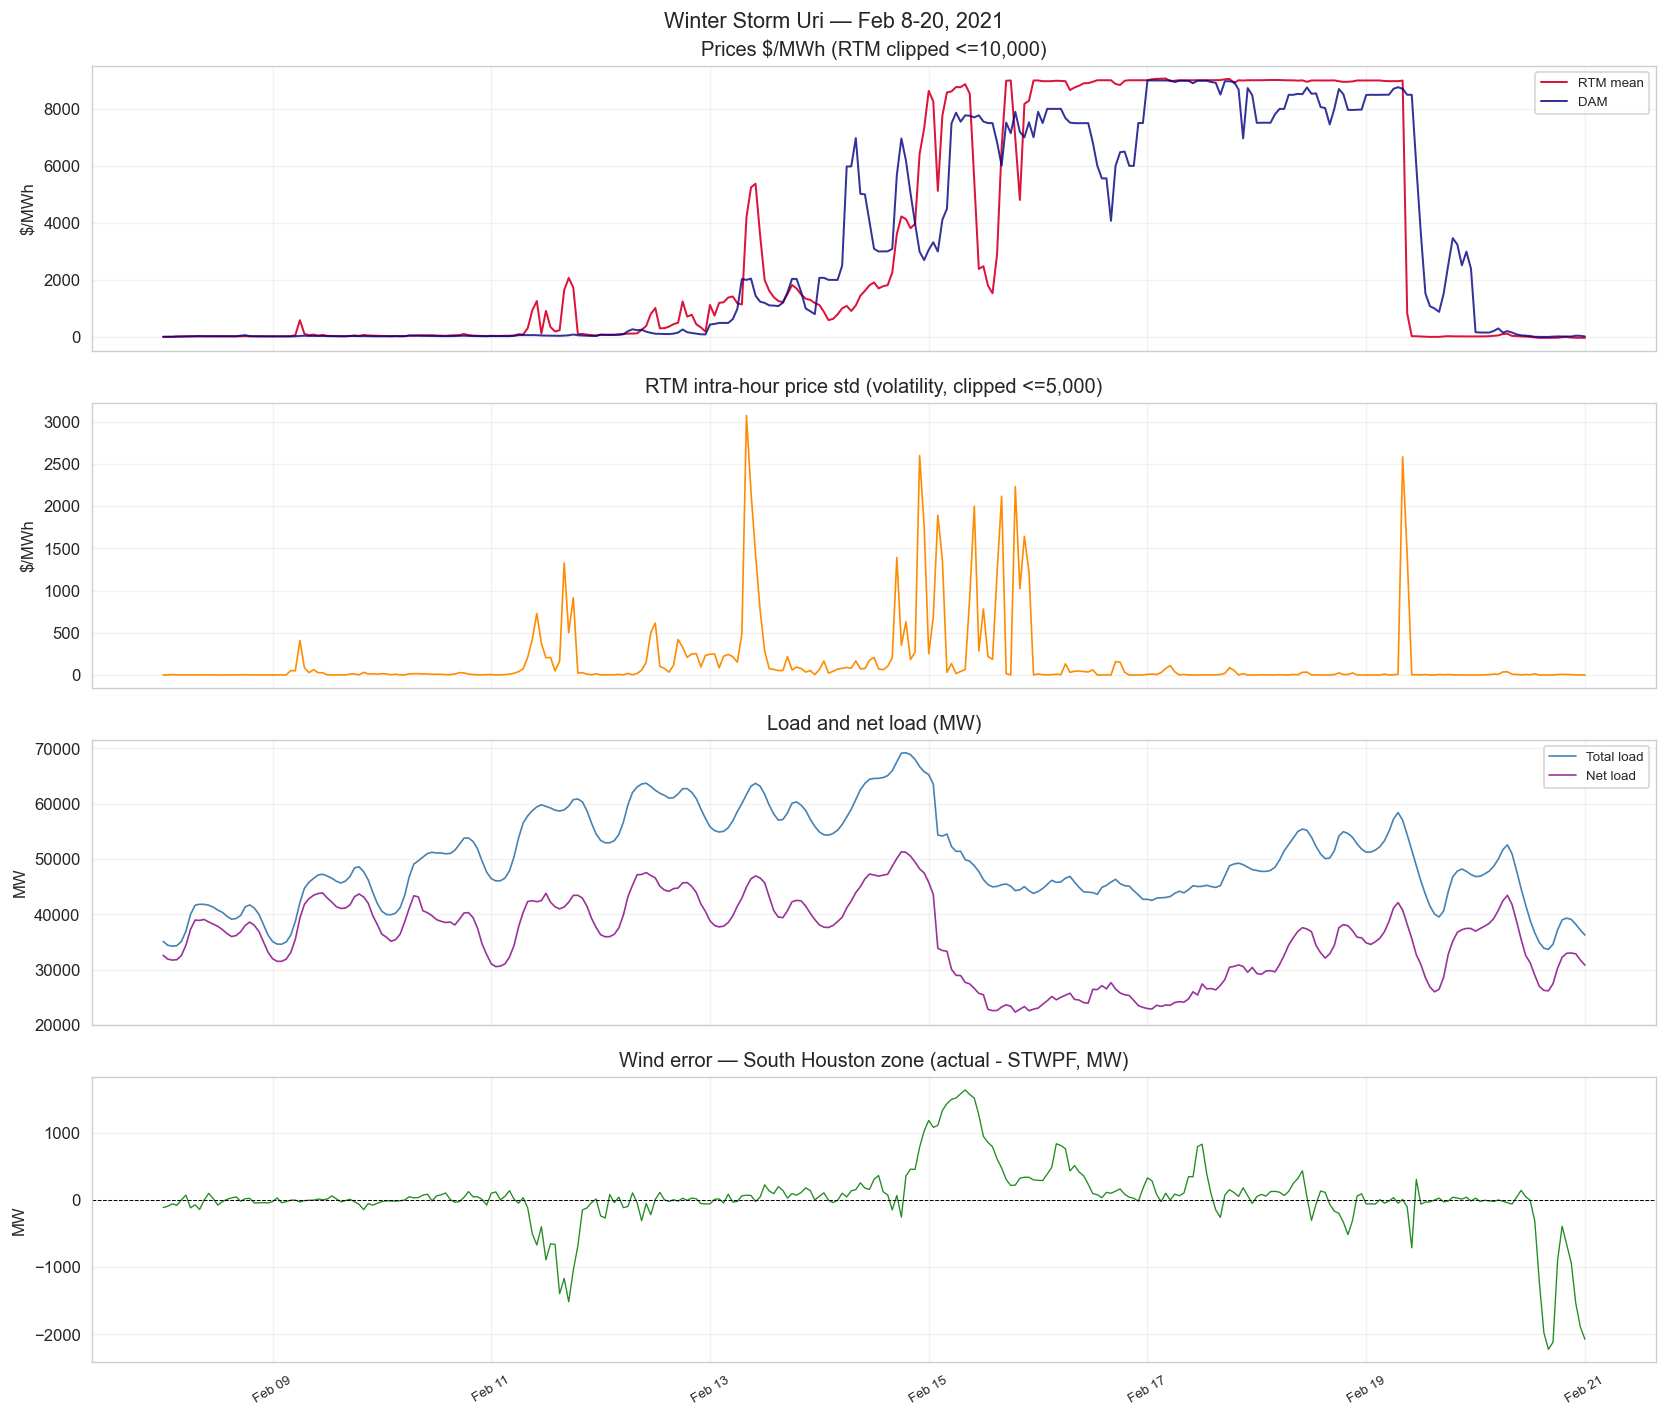

In [23]:
# Winter Storm Uri zoom
_lo, _hi = pd.Timestamp('2021-02-08'), pd.Timestamp('2021-02-21')
_uri = df[(df['ts_cst'] >= _lo) & (df['ts_cst'] <= _hi)].copy()

fig, axes = plt.subplots(4, 1, figsize=(14, 12), sharex=True)
fig.suptitle('Winter Storm Uri — Feb 8-20, 2021', fontsize=13)

axes[0].plot(_uri['ts_cst'], _uri['rtm_price_mean_hb_houston'].clip(upper=10000),
             lw=1.2, color='crimson', label='RTM mean')
axes[0].plot(_uri['ts_cst'], _uri['dam_price_houston'],
             lw=1.2, color='navy', alpha=0.8, label='DAM')
axes[0].set_title('Prices $/MWh (RTM clipped <=10,000)'); axes[0].set_ylabel('$/MWh')
axes[0].legend(fontsize=8)

axes[1].plot(_uri['ts_cst'], _uri['rtm_price_std_hb_houston'].clip(upper=5000),
             lw=1.0, color='darkorange')
axes[1].set_title('RTM intra-hour price std (volatility, clipped <=5,000)'); axes[1].set_ylabel('$/MWh')

axes[2].plot(_uri['ts_cst'], _uri['load_total'], lw=1.0, color='steelblue', label='Total load')
if 'net_load_mw' in _uri.columns:
    axes[2].plot(_uri['ts_cst'], _uri['net_load_mw'], lw=1.0, color='purple',
                 alpha=0.8, label='Net load')
axes[2].set_title('Load and net load (MW)'); axes[2].set_ylabel('MW'); axes[2].legend(fontsize=8)

axes[3].plot(_uri['ts_cst'], _uri['wind_error_houston'], lw=0.8, color='forestgreen')
axes[3].axhline(0, color='black', lw=0.6, linestyle='--')
axes[3].set_title('Wind error — South Houston zone (actual - STWPF, MW)'); axes[3].set_ylabel('MW')

for ax in axes:
    ax.xaxis.set_major_locator(mdates.DayLocator(interval=2))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %d'))
    ax.tick_params(axis='x', rotation=30, labelsize=8)
    ax.grid(alpha=0.25)

plt.tight_layout()
plt.show()

### 4.2 High-Volatility Hours — seasonal and diurnal concentration

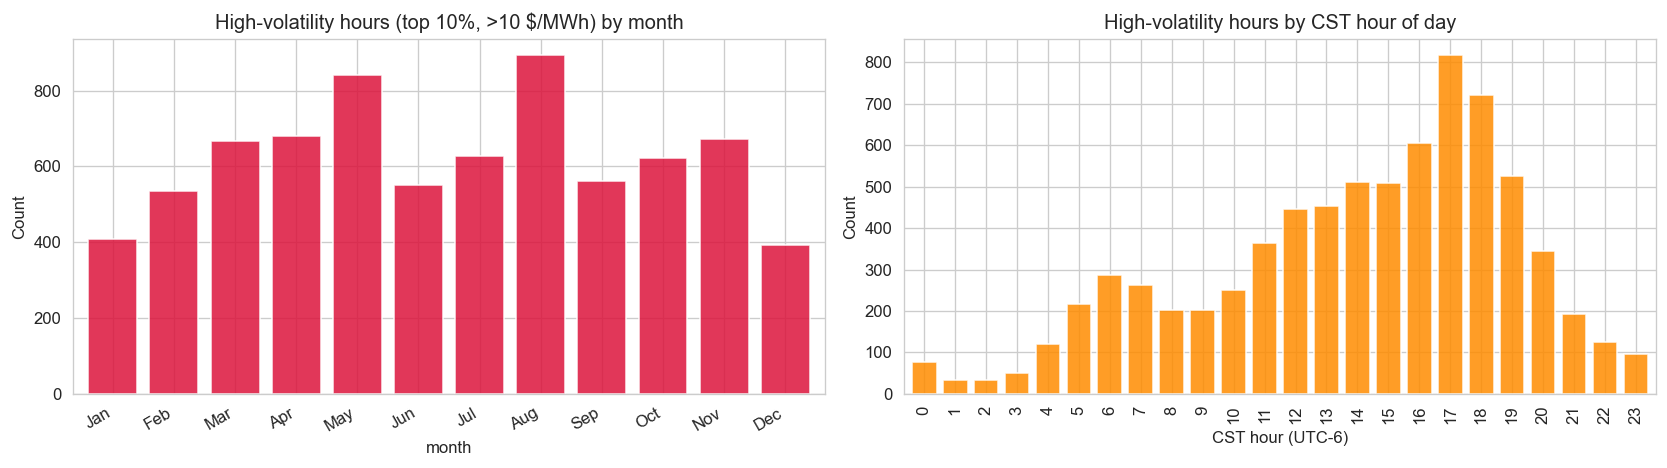

p90 threshold: 10.3 $/MWh
High-vol hours by season:
season
summer    2634
spring    2188
winter    1339
fall      1294
dtype: int64


In [24]:
# Top-10% most volatile hours: breakdown by month and hour of day
_p90 = df['rtm_price_std_hb_houston'].quantile(0.90)
_hi_vol = df[df['rtm_price_std_hb_houston'] > _p90].copy()

fig, axes = plt.subplots(1, 2, figsize=(14, 4))
_months = ['Jan','Feb','Mar','Apr','May','Jun','Jul','Aug','Sep','Oct','Nov','Dec']

_hi_vol.groupby('month').size().plot(
    kind='bar', ax=axes[0], color='crimson', alpha=0.85, width=0.8)
axes[0].set_title(f'High-volatility hours (top 10%, >{_p90:.0f} $/MWh) by month')
axes[0].set_xticklabels(_months, rotation=30, ha='right')
axes[0].set_ylabel('Count')

_hi_vol.groupby('hour').size().plot(
    kind='bar', ax=axes[1], color='darkorange', alpha=0.85, width=0.8)
axes[1].set_title('High-volatility hours by CST hour of day')
axes[1].set_xlabel('CST hour (UTC-6)'); axes[1].set_ylabel('Count')

plt.tight_layout()
plt.show()

print(f'p90 threshold: {_p90:.1f} $/MWh')
print('High-vol hours by season:')
print(_hi_vol.groupby('season').size().sort_values(ascending=False))

### 4.3 Autocorrelation of Volatility — persistence justifies lag features

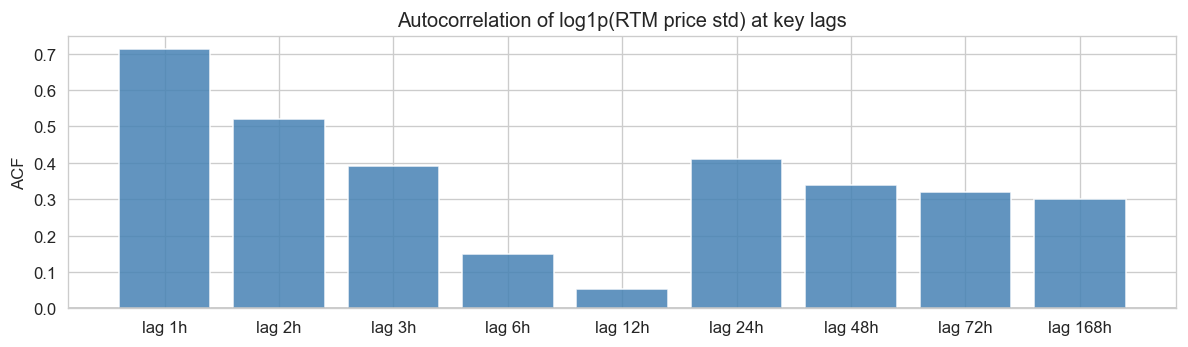

  lag   1h: 0.7128
  lag   2h: 0.5200
  lag   3h: 0.3908
  lag   6h: 0.1504
  lag  12h: 0.0526
  lag  24h: 0.4114
  lag  48h: 0.3379
  lag  72h: 0.3208
  lag 168h: 0.3011


In [25]:
# Autocorrelation of log-volatility at key lags
_lv = df.set_index('ts_cst')['rtm_price_std_hb_houston'].dropna()
_log_lv = np.log1p(_lv)

lags = [1, 2, 3, 6, 12, 24, 48, 72, 168]
acf_vals = {lag: _log_lv.autocorr(lag=lag) for lag in lags}

fig, ax = plt.subplots(figsize=(10, 3))
ax.bar(range(len(lags)), list(acf_vals.values()), color='steelblue', alpha=0.85)
ax.axhline(0, color='black', lw=0.8)
ax.set_xticks(range(len(lags)))
ax.set_xticklabels([f'lag {l}h' for l in lags])
ax.set_title('Autocorrelation of log1p(RTM price std) at key lags')
ax.set_ylabel('ACF')
plt.tight_layout()
plt.show()

for lag, val in acf_vals.items():
    print(f'  lag {lag:>3}h: {val:.4f}')

## 5. Modeling Roadmap

This section ties together the EDA findings and lays out the modeling strategy: which features to use, what targets to predict, and how to avoid data leakage.


### 5.1 Feature Correlation with Log-Volatility

Pearson correlation of each candidate feature with `log_rtm_std`. Features with |r| > 0.10 are strong linear candidates; lower-correlation features may still be useful non-linearly in tree models.


In [26]:
# Correlation of candidate features with log-volatility
# Note: wgrpp_lz_south_houston (realized wind generation, D-2 lag) is a v3 base feature
# but omitted from this EDA plot. We show wind_error_houston (forecast error, strong spike signal)
# and wf_stwpf_lz_south_houston (wind forecast, available at midnight) instead —
# derived/forecast signals are more informative for EDA than raw generation level.
_feature_cols = [
    'net_load_mw', 'load_total', 're_share', 'total_resource_mw',
    'wind_error_houston', 'wf_stwpf_lz_south_houston',
    'dam_price_houston', 'dam_rtm_spread_houston',
    'system_lambda',
    'fc_coast_std_48h', 'wf_stwpf_lz_south_houston_std_48h',
    'outf_total_resource_mw_std_48h',
    'mcpc_rrs', 'mcpc_regup'
]
df[_feature_cols].corrwith(df['rtm_price_std_hb_houston'])

net_load_mw                          0.132328
load_total                           0.144636
re_share                             0.066823
total_resource_mw                   -0.003933
wind_error_houston                  -0.008950
wf_stwpf_lz_south_houston            0.015534
dam_price_houston                    0.247661
dam_rtm_spread_houston              -0.323839
system_lambda                        0.246199
fc_coast_std_48h                     0.082191
wf_stwpf_lz_south_houston_std_48h   -0.011148
outf_total_resource_mw_std_48h      -0.009436
mcpc_rrs                             0.128480
mcpc_regup                           0.121709
dtype: float64

### 5.2 Modeling Plan

#### Target variables

| Target | Type | Notes |
|---|---|---|
| `log1p(rtm_price_std_hb_houston)` | Regression | Primary. Log stabilizes right-skewed distribution. Evaluate via MAE/RMSE on original scale (`expm1`). |
| `rtm_price_mean_hb_houston > $100/MWh` | Binary classification | Secondary (`spike_flag`). Severe class imbalance — use precision-recall AUC, not accuracy. |

#### Feature tiers

| Tier | Features | Why |
|---|---|---|
| 1 | `net_load_mw`, `net_load_mw^2`, `wind_error_houston`, `dam_price_houston` (lag 24h), `total_resource_mw` | Direct physical drivers of price spikes |
| 2 | `fc_system_total_std_48h`, `wf_stwpf_lz_south_houston_std_48h`, `outf_total_resource_mw_std_48h`, `mcpc_rrs`, `mcpc_regup`, `dam_rtm_spread_houston` (lag 24h) | Forward-looking uncertainty + reserve signals |
| 3 | `hour`, `month`, `season`, `is_peak`, `weekday` | Diurnal / seasonal regime |
| Lags | `rtm_price_std` at 24h, 48h, 168h; `wind_error_houston` at 1h, 2h | Volatility autocorrelation |

#### D+1 leakage rule

See the **"Data Design: Two Separate Jobs"** section above for the full data availability table and the correct feature-building pattern using individual parquets + `post_datetime` filter.

Summary for modeling:
- **Use directly (posted D-1 noon):** `dam_price_*`, `system_lambda`, `mcpc_*`, all `fc_*`/`wf_*`/`outf_*` forecasts
- **Use D-2 lag:** `load_houston`, `load_total`, `wz_*` zone loads, `wind_error_*`, `rtm_price_*`
- **Do not use from `ercot_combined`** — build features from individual parquets with `post_datetime <= cutoff`

#### Models (execution order)

| Step | Model | Purpose |
|---|---|---|
| 1 | Seasonal naive: `rtm_price_std` at same hour, 1 week prior | Baseline to beat |
| 2 | Ridge Regression on `log1p(vol)` with polynomial `net_load_mw` | Transparent linear baseline |
| 3 | SARIMA(1,0,1)(1,0,1,24)-X | Time-series baseline; validates that tabular features add signal beyond autocorrelation |
| 4 | **XGBoost** on `log1p(vol)` with time-series CV | Primary model; handles nonlinearity and extreme hours naturally |
| 5 | Random Forest with `class_weight='balanced'` | Spike classification (secondary target) |

#### Validation strategy — expanding window (never random split)

```
Fold 1: train 2017-07 -> 2021-12,  validate 2022
Fold 2: train 2017-07 -> 2022-12,  validate 2023
Fold 3: train 2017-07 -> 2023-12,  validate 2024
Out-of-sample test: 2025 (clean holdout, never used for model selection)
Hold-out: 2026 (untouched until model is locked)
```

All 3 CV folds are within the training period (≤2024). The 2025 test set is never touched during model selection.

#### Evaluation metrics

- **Overall:** MAE and RMSE on original scale (`expm1` predictions)
- **Stratified:** Report separately on top-10% most volatile hours — this is where operational value lies
- **Classification:** Precision-recall AUC on spike hours

Any model must beat the seasonal naive baseline **on the top-decile volatile hours** to be considered useful.

### 5.3 Data Design for Modeling

Modeling requires two separate tables with different design goals:

**`ercot_combined.parquet` — EDA only (do not use as model input)**  
Aligns all datasets by *delivery time* (`ts_cst`). Contains actual realized values regardless of when ERCOT published them — this introduces data leakage if used directly as features. Useful for EDA correlations, distributions, and visualisations (Sections 2–5).

**Individual parquets — model features via `build_features()`**  
Each parquet has a `post_datetime` column recording when ERCOT published that row. The `build_features(delivery_date)` function filters each dataset to only rows available at **00:05 CST** (12:05 AM CST on delivery day D), guaranteeing no look-ahead leakage. The 5-minute buffer past midnight is needed because the RTM last 15-min interval (required for hour-23's 5-point std) posts at ~00:02 CST.

| Dataset | Available at 00:05 CST? | Lag used |
|---|---|---|
| DAM prices (NP4-190) | ✅ Published ~06:33 CST D-1 | Same-day D |
| Ancillary MCPC (NP4-188) | ✅ Same as DAM | Same-day D |
| RTM prices (NP6-905) | ✅ Last interval ~00:02 CST D (before cutoff) | **D-1 lag (24h)** |
| Load actuals (NP6-346) | ❌ Posts ~05:50 CST D (after cutoff) | **D-2 lag (48h)** |
| Wind actuals (NP4-732) | ❌ Last update ~00:31 CST D (after cutoff) | **D-2 lag (48h)** |
| Outage capacity (NP3-233) | ✅ Latest hourly revision before cutoff | Most recent |
| Load/wind forecasts (NP3-565, NP4-732-fc) | ✅ Updated through 23:30/23:42 CST D-1 | Direct |

D-2 lag (48h) applies to load and wind actuals: `load_houston_lag48`, `wgrpp_lz_south_houston`, `wind_error_houston`.  
D-1 lag (24h) applies to RTM: `rtm_mean_lag24`, `rtm_std_lag24` — the prior delivery day's actuals shifted forward 1 day so hours align with the delivery day being predicted.


In [27]:
from pathlib import Path
import pandas as pd
import numpy as np

_PROC = Path('data/processed/ercot')

def build_features(delivery_date, _cache=None):
    """
    Build a leakage-safe (24, n_features) feature matrix for a given delivery date.
    Uses only data available at 00:05 CST (12:05 AM CST of delivery day D).

    Cutoff is 00:05 CST (not midnight) because the RTM last 15-min interval
    posts at ~00:02 CST — needed for the 5-point std of hour 23. With 5 minutes
    of margin all D-1 RTM data is safely available.

    Both ts_cst and post_datetime in parquets are stored in CST (local clock time,
    UTC-6 in winter / UTC-5 in summer — raw ERCOT values, no conversion applied).

    Data availability at 00:05 CST D:
    - DAM/ancillary/lambda post at ~06:33 CST D-1 → D-day values available ✓
    - Actual load (346) posts at ~05:50 CST D (after cutoff) → D-1 NOT available; use D-2 lag ✗
    - RTM prices last interval at 00:02 CST D → available at 00:05; use D-1 lag ✓
    - Wind actuals last update ~00:31 CST D (after cutoff) → D-1 NOT available; use D-2 lag ✗
    - Wind/load forecasts update through ~23:30/23:42 CST D-1 → available ✓
    - Outage capacity latest hourly revision before cutoff → available ✓

    Houston-first design: where Houston/Coast-specific data exists, it is used.
    System-wide is used only when no zone-level alternative is available.

    Parameters
    ----------
    delivery_date : pd.Timestamp or date
    _cache : dict, optional
        Pre-loaded parquet DataFrames keyed by dataset name.
        Pass this when looping over many dates for a large speedup.

    Returns
    -------
    pd.DataFrame, shape (24, n_features), indexed by ts_cst (delivery hours, CST)
    """
    delivery_date = pd.Timestamp(delivery_date)
    cutoff  = delivery_date + pd.Timedelta(minutes=5)  # 00:05 CST D (12:05 AM)
    d2_start = delivery_date - pd.Timedelta(days=2)   # D-2 for load & wind actuals
    d1_start = delivery_date - pd.Timedelta(days=1)   # D-1 for RTM (available at 00:05)

    def _load(name):
        if _cache is not None:
            return _cache[name]
        return pd.read_parquet(_PROC / f'{name}.parquet')

    def _avail(df):
        return df[df['post_datetime'] <= cutoff]

    def _day(df, start):
        """Vectorized day filter: returns rows where ts_cst is within [start, start+23h]."""
        end = start + pd.Timedelta(hours=23)
        return df[(df['ts_cst'] >= start) & (df['ts_cst'] <= end)]

    # --- DAM prices — Houston hub (Houston-specific ✓) ---
    dam = _day(_avail(_load('np4_190_dam_houston')), delivery_date)[['ts_cst', 'dam_price_houston']]

    # --- System lambda (no Houston-zone version; system-wide only) ---
    lam = _day(_avail(_load('np4_523_system_lambda')), delivery_date)[['ts_cst', 'system_lambda']]

    # --- Ancillary MCPC (system-wide; no zonal ancillary clearing prices in ERCOT) ---
    # ECRS excluded — only available 2021-06+, insufficient pre-Uri history
    anc_cols = ['mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn']
    anc_dfs = []
    for col in anc_cols:
        a = _day(_avail(_load(f'np4_188_{col}')), delivery_date)[['ts_cst', col]]
        anc_dfs.append(a)

    # --- Load actuals D-2 lag — Houston pricing zone (Houston-specific ✓) ---
    # Posts ~05:50 CST D (after 00:05 cutoff) → D-1 not available; use D-2 (48h lag)
    load_raw = _day(_avail(_load('np6_346_houston')), d2_start)[['ts_cst', 'houston']].copy()
    load_raw['ts_cst'] = load_raw['ts_cst'] + pd.Timedelta(days=2)
    load_raw = load_raw.rename(columns={'houston': 'load_houston_lag48'})

    # --- RTM prices D-1 lag — Houston hub (Houston-specific ✓) ---
    # Last interval posts ~00:02 CST D → available at 00:05 CST cutoff; D-1 safe ✓
    rtm_raw = _day(_avail(_load('np6_905_rtm_hourly_houston')), d1_start)[['ts_cst', 'rtm_price_mean', 'rtm_price_std']].copy()
    rtm_raw['ts_cst'] = rtm_raw['ts_cst'] + pd.Timedelta(days=1)
    rtm_raw = rtm_raw.rename(columns={'rtm_price_mean': 'rtm_mean_lag24', 'rtm_price_std': 'rtm_std_lag24'})

    # --- Outage capacity — system-wide (no Houston-zone parquet available) ---
    out = _day(_avail(_load('np3_233_outage_total')), delivery_date)[['ts_cst', 'total_resource_mw']]
    if out.empty:
        out_all = _avail(_load('np3_233_outage_total'))
        latest_val = out_all.sort_values('post_datetime').iloc[-1]['total_resource_mw']
        out = pd.DataFrame({'ts_cst': pd.date_range(delivery_date, periods=24, freq='h'),
                            'total_resource_mw': latest_val})

    # --- Wind actuals D-2 lag — South Houston zone (Houston-specific ✓) ---
    # Last update ~00:31 CST D (after 00:05 cutoff) → D-1 not available; use D-2 (48h lag)
    wind_raw = _day(_avail(_load('np4_732_wind_houston')), d2_start)[['ts_cst', 'wgrpp_lz_south_houston', 'wind_error_houston']].copy()
    wind_raw['ts_cst'] = wind_raw['ts_cst'] + pd.Timedelta(days=2)

    # --- Load forecast — Coast zone primary (Houston area ✓); system total as complement ---
    fc = _day(_load('np3_565_forecast1'), delivery_date)[['ts_cst', 'fc_coast', 'fc_system_total']]

    # --- Wind forecast — South Houston zone (Houston-specific ✓, replaces system-wide) ---
    wfc = _day(_load('np4_732_forecast1'), delivery_date)[['ts_cst', 'wf_stwpf_lz_south_houston']]

    # --- Weather — Houston avg (Houston-first ✓, all 4 variables Houston-specific) ---
    wx_cols = ['ts_cst', 'temp_f_houston_avg', 'humidity_pct_houston_avg',
               'wind_gust_mph_houston_avg', 'precip_in_houston_avg']
    wx = _day(_load('weather_hourly'), delivery_date)[wx_cols]

    # --- Merge all onto delivery-day ts_cst spine ---
    spine = pd.DataFrame({'ts_cst': pd.date_range(delivery_date, periods=24, freq='h')})
    feats = spine.copy()
    for d in [dam, lam, load_raw, rtm_raw, out, wind_raw, fc, wfc, wx] + anc_dfs:
        feats = feats.merge(d, on='ts_cst', how='left')

    # --- Calendar features ---
    feats['hour']  = feats['ts_cst'].dt.hour
    feats['month'] = feats['ts_cst'].dt.month
    feats['dow']   = feats['ts_cst'].dt.dayofweek

    return feats.set_index('ts_cst')


# --- Quick test: build features for one delivery date ---
test_date = pd.Timestamp('2024-06-15')
feats = build_features(test_date)
print(f"Feature matrix shape: {feats.shape}")
print(f"Columns ({len(feats.columns)}): {list(feats.columns)}")
print(f"\nNull counts:")
print(feats.isnull().sum()[feats.isnull().sum() > 0].to_string() or "  None")


Feature matrix shape: (24, 22)
Columns (22): ['dam_price_houston', 'system_lambda', 'load_houston_lag48', 'rtm_mean_lag24', 'rtm_std_lag24', 'total_resource_mw', 'wgrpp_lz_south_houston', 'wind_error_houston', 'fc_coast', 'fc_system_total', 'wf_stwpf_lz_south_houston', 'temp_f_houston_avg', 'humidity_pct_houston_avg', 'wind_gust_mph_houston_avg', 'precip_in_houston_avg', 'mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn', 'hour', 'month', 'dow']

Null counts:
dam_price_houston     1
system_lambda         1
load_houston_lag48    1
rtm_mean_lag24        1
rtm_std_lag24         1
mcpc_regup            1
mcpc_rrs              1
mcpc_nspin            1
mcpc_regdn            1


## Appendix A. Feature Dictionary

All features are constructed to be available at the **midnight CST prediction cutoff** (no leakage).
The table below explains each of the **v3 base features (22 features stored in train_features.parquet; v3 adds GARCH + 7 engineered features in modeling.ipynb)**.

**Houston-first design**: where Houston or Coast-specific data exists, it is used in preference to system-wide aggregates. System-wide data is used only where no zone-level alternative is available.

Note: `mcpc_ecrs` and its 3 derived features are listed below for reference but are **excluded from all models** — ECRS launched June 2021, giving insufficient pre-Uri history.

---

### Market Price Features

| Feature | Source | Availability | Why it matters |
|---|---|---|---|
| `dam_price_houston` | NP4-190 DAM settlement | D-1 ~noon UTC | Day-ahead market price for HB_HOUSTON hub. Captures the market's consensus expectation of delivery-day value. High DAM prices signal tight supply and tend to precede RTM volatility. |
| `system_lambda` | NP4-523 DAM system lambda | D-1 ~noon UTC | Marginal cost of energy at DAM clearing. System-level (no Houston-specific version exists). Divergence from hub price indicates congestion. |
| `rtm_mean_lag24` | NP6-905 RTM — Houston hub (D-2) | D-2 complete | 48-hour lag of realized RTM price mean at HB_HOUSTON. Captures persistence of price regime. |
| `rtm_std_lag24` | NP6-905 RTM — Houston hub (D-2) | D-2 complete | 48-hour lag of realized RTM price volatility (5-point std). Strong autocorrelation in volatility (GARCH effect) makes this one of the most predictive features. |

---

### Ancillary Service Prices

These reflect the DAM-cleared prices for reserve products. No zonal clearing prices exist in ERCOT — all ancillary prices are system-wide.

| Feature | Source | Why it matters |
|---|---|---|
| `mcpc_regup` | NP4-188 MCPC Reg-Up | Regulation-up reserve scarcity → RTM price spikes when committed capacity is tight |
| `mcpc_regdn` | NP4-188 MCPC Reg-Down | Regulation-down reserve → indicates oversupply risk (negative price events) |
| `mcpc_rrs` | NP4-188 MCPC RRS | Responsive reserve service — proxy for spinning reserve margin |
| `mcpc_nspin` | NP4-188 MCPC Non-Spin | Non-spinning reserve — elevated prices suggest offline backup capacity is scarce |
| `mcpc_ecrs` | NP4-188 MCPC ECRS | **Excluded** — ERCOT Contingency Reserve Service (launched ~2021); insufficient pre-Uri history |

---

### Load & Supply Features

| Feature | Source | Availability | Why it matters |
|---|---|---|---|
| `load_houston_lag48` | NP6-346 — Houston pricing zone (D-2) | D-2 complete | Realized Houston zone load two days prior. Load is highly autocorrelated day-over-day, so D-2 is a strong predictor of delivery-day demand. Houston-specific ✓ |
| `fc_coast` | NP3-565 load forecast — Coast zone | midnight CST baked in | ERCOT's load forecast for the Coast weather zone (covers Houston hub area). Best available Houston-area demand signal at prediction time. Houston/Coast ✓ |
| `fc_system_total` | NP3-565 load forecast — system total | midnight CST baked in | System-total load forecast. Used as complement to `fc_coast` and for `outage_fraction`. |
| `total_resource_mw` | NP3-233 outage data | Latest posting ≤ cutoff | Total MW of planned outage capacity, system-wide. No Houston-zone parquet available for full history. |

---

### Wind Features

| Feature | Source | Availability | Why it matters |
|---|---|---|---|
| `wgrpp_lz_south_houston` | NP4-732 wind actuals — South Houston zone (D-2) | D-2 complete | Realized wind generation resource production potential for the South Houston load zone, two days prior. Houston-specific ✓ — directly captures local wind conditions affecting the Houston hub. |
| `wind_error_houston` | NP4-732 wind actuals — South Houston zone (D-2) | D-2 complete | Forecast error = actual − STWPF forecast for South Houston on D-2. Houston-specific ✓ — persistent errors indicate model bias under specific local weather regimes. |
| `wf_stwpf_lz_south_houston` | NP4-732 wind forecast — South Houston zone | midnight CST baked in | ERCOT's STWPF wind forecast for the South Houston load zone. Houston-specific ✓ — captures local wind generation that directly affects Houston hub congestion and prices. |

---

### Weather Features

Weather data is from ground stations (historical actuals used as proxy for day-ahead forecast, which is highly accurate for temperature at 24h horizon). All Houston-specific ✓ — only Houston weather variables are used as features.

| Feature | Source | Why it matters |
|---|---|---|
| `temp_f_houston_avg` | Houston weather stations avg | Primary driver of AC load demand. Summer heat waves push load → capacity tightness → volatility. |
| `humidity_pct_houston_avg` | Houston weather stations avg | High humidity amplifies AC load at a given temperature (heat index effect). |
| `wind_gust_mph_houston_avg` | Houston weather stations avg | Local wind speed affects Houston-area wind generation and transmission constraints. |
| `precip_in_houston_avg` | Houston weather stations avg | Precipitation events correlated with storm-driven load spikes and wind variability. |

---

### Calendar Features

| Feature | Why it matters |
|---|---|
| `hour` | Strong diurnal pattern — morning ramp (7–9 AM) and evening peak (6–8 PM) are consistently highest-volatility periods |
| `month` | Captures seasonal effects: summer AC load, winter heating demand, spring/fall low-demand periods |
| `dow` | Day-of-week captures weekday vs weekend demand differences (~15% lower load on weekends → different price regime) |

In [28]:
import time

# ── Pre-load all parquets once (avoids repeated disk reads in the loop) ────────
_DATASETS = [
    'np4_190_dam_houston', 'np4_523_system_lambda',
    'np4_188_mcpc_regup', 'np4_188_mcpc_rrs',
    'np4_188_mcpc_nspin', 'np4_188_mcpc_regdn',
    'np6_346_houston', 'np6_905_rtm_hourly_houston',
    'np3_233_outage_total', 'np4_732_wind_houston',
    'np3_565_forecast1', 'np4_732_forecast1', 'weather_hourly',
]
print("Loading parquets into memory...")
t0 = time.time()
_CACHE = {name: pd.read_parquet(_PROC / f'{name}.parquet') for name in _DATASETS}
print(f"  Done in {time.time()-t0:.1f}s")

# ── Build training matrix (2017-07-04 → 2024-12-31) ──────────────────────────
TRAIN_START = pd.Timestamp('2017-07-04')
TRAIN_END   = pd.Timestamp('2024-12-31 23:00')
TEST_START  = pd.Timestamp('2025-01-01')
TEST_END    = pd.Timestamp('2025-12-31')

def _build_range(start, end, label):
    dates = pd.date_range(start, end, freq='D')
    rows, errors = [], []
    t0 = time.time()
    for i, d in enumerate(dates):
        try:
            rows.append(build_features(d, _cache=_CACHE))
        except Exception as e:
            errors.append((d, str(e)))
        if (i + 1) % 500 == 0:
            print(f"  {label}: {i+1}/{len(dates)} dates ({time.time()-t0:.0f}s elapsed)")
    df = pd.concat(rows)
    if errors:
        print(f"  ⚠️  {len(errors)} errors: {errors[:5]}")
    print(f"  {label}: {df.shape[0]} rows × {df.shape[1]} cols, {time.time()-t0:.0f}s total")
    return df

print("\nBuilding TRAIN features (2017-07-04 → 2024-12-31)...")
train_feats = _build_range(TRAIN_START, TRAIN_END, "train")

print("\nBuilding TEST features (2025-01-01 → 2025-12-31)...")
test_feats = _build_range(TEST_START, TEST_END, "test")

# ── Join targets (RTM actuals from np6_905) ────────────────────────────────────
rtm = _CACHE['np6_905_rtm_hourly_houston'].set_index('ts_cst')[['rtm_price_std', 'rtm_price_mean']]

def _add_targets(df):
    df = df.join(rtm, how='left')
    df['log_rtm_std']  = np.log1p(df['rtm_price_std'])
    df['spike_flag']   = (df['rtm_price_mean'] > 100).astype('Int8')
    return df

train_feats = _add_targets(train_feats)
test_feats  = _add_targets(test_feats)

Loading parquets into memory...
  Done in 0.0s

Building TRAIN features (2017-07-04 → 2024-12-31)...


  train: 500/2738 dates (8s elapsed)


  train: 1000/2738 dates (16s elapsed)


  train: 1500/2738 dates (25s elapsed)


  train: 2000/2738 dates (35s elapsed)


  train: 2500/2738 dates (47s elapsed)


  train: 65712 rows × 22 cols, 53s total

Building TEST features (2025-01-01 → 2025-12-31)...


  test: 8760 rows × 22 cols, 10s total


## Appendix B: Cross-Feature EDA
We investigate for strong relationships between features that would suggest we should drop some of them so as to prevent overfitting or model instability. We will set a threshold of `corr > 0.95` as our benchmark for dropping something, and `corr > 0.9` as a benchmark for keeping it on our radar when later interpreting the models.

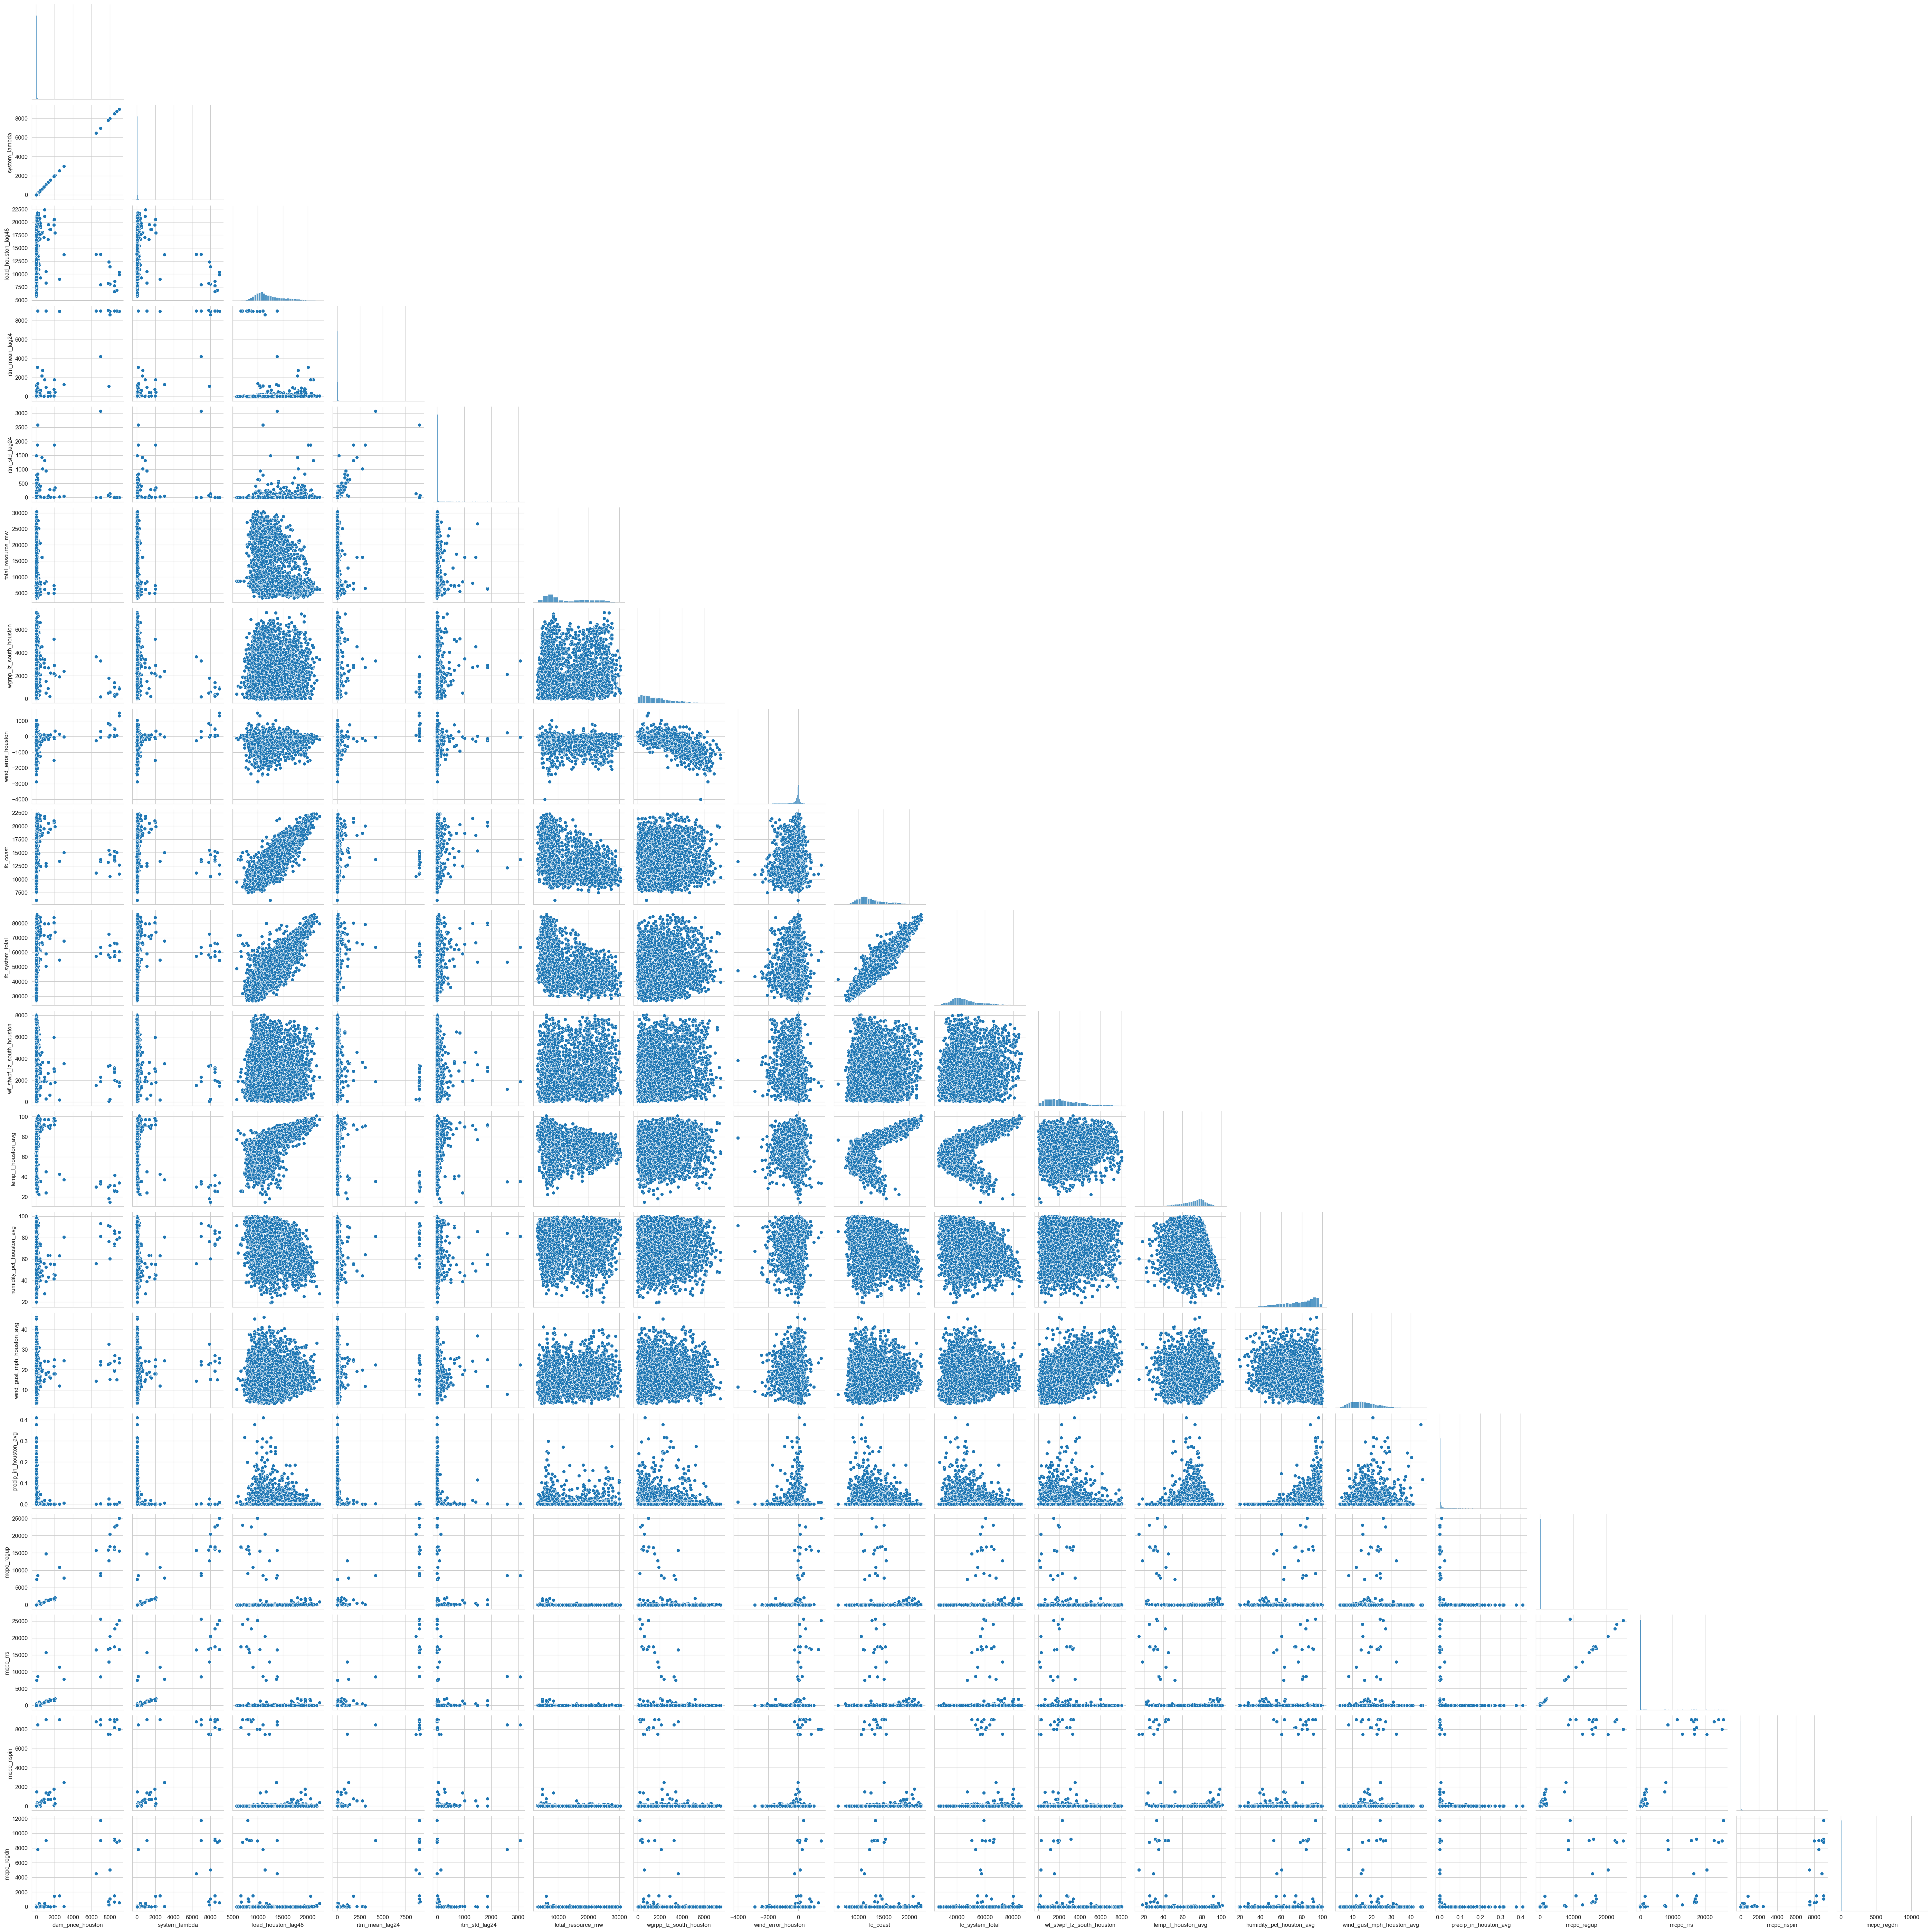

In [29]:
temp_train_feats = train_feats.drop(columns=['rtm_price_std', 'rtm_price_mean', 'log_rtm_std', 'spike_flag', 'hour', 'month', 'dow'])
sns.pairplot(temp_train_feats.sample(5000), corner=True)
plt.show()

There appears to be a significant nonlinear relationship between `temp_f_houston_avg` and `fc_coast`, so let's calculate the correlation matrix only after linearizing this relationship.

In [30]:
p = np.poly1d(np.polyfit(temp_train_feats['temp_f_houston_avg'], temp_train_feats['fc_coast'], 2))
temp_train_feats['q_temp_houston'] = p(temp_train_feats['temp_f_houston_avg'])
corr_matrix = temp_train_feats.corr()
np.trunc(corr_matrix * 10**4) / 10**4

,dam_price_houston,system_lambda,load_houston_lag48,rtm_mean_lag24,rtm_std_lag24,total_resource_mw,wgrpp_lz_south_houston,wind_error_houston,fc_coast,fc_system_total,wf_stwpf_lz_south_houston,temp_f_houston_avg,humidity_pct_houston_avg,wind_gust_mph_houston_avg,precip_in_houston_avg,mcpc_regup,mcpc_rrs,mcpc_nspin,mcpc_regdn,q_temp_houston
dam_price_houston,1.0000,0.9996,0.0541,0.7987,0.2407,-0.0640,0.0015,0.0461,0.0998,0.1509,-0.0108,-0.0814,-0.0651,0.0670,-0.0039,0.8876,0.9176,0.8963,0.7360,0.1417
system_lambda,0.9996,1.0000,0.0503,0.7977,0.2378,-0.0722,-0.0007,0.0479,0.0953,0.1482,-0.0156,-0.0858,-0.0616,0.0627,-0.0035,0.8877,0.9177,0.8963,0.7359,0.1375
load_houston_lag48,0.0541,0.0503,1.0000,0.0308,0.1429,-0.3738,0.1134,0.0212,0.8996,0.8561,0.0423,0.6752,-0.3272,0.0807,0.0196,-0.0126,-0.0183,0.0007,-0.0213,0.8126
rtm_mean_lag24,0.7987,0.7977,0.0308,1.0000,0.3773,-0.0345,-0.0033,0.0470,0.0731,0.1135,-0.0074,-0.0779,-0.0421,0.0397,-0.0027,0.8257,0.8532,0.8478,0.6999,0.1013
rtm_std_lag24,0.2407,0.2378,0.1429,0.3773,1.0000,-0.0238,0.0403,-0.0129,0.1469,0.1605,0.0199,0.0562,-0.0933,0.0420,-0.0009,0.1578,0.1669,0.1961,0.1587,0.1592
total_resource_mw,-0.0640,-0.0722,-0.3738,-0.0345,-0.0238,1.0000,0.1399,-0.1344,-0.3875,-0.4315,0.1574,-0.2400,0.0050,0.1699,0.0096,-0.0262,-0.0023,-0.0118,-0.0112,-0.4156
wgrpp_lz_south_houston,0.0015,-0.0007,0.1134,-0.0033,0.0403,0.1399,1.0000,-0.6303,0.0875,0.1250,0.2753,-0.0344,-0.0806,0.1243,-0.0302,-0.0141,-0.0159,-0.0097,-0.0141,0.0142
wind_error_houston,0.0461,0.0479,0.0212,0.0470,-0.0129,-0.1344,-0.6303,1.0000,0.0227,-0.0078,-0.1794,0.0891,0.0369,-0.0593,0.0102,0.0555,0.0569,0.0533,0.0533,0.0780
fc_coast,0.0998,0.0953,0.8996,0.0731,0.1469,-0.3875,0.0875,0.0227,1.0000,0.9473,0.0885,0.6951,-0.3112,0.1082,-0.0029,0.0347,0.0253,0.0479,0.0180,0.8967
fc_system_total,0.1509,0.1482,0.8561,0.1135,0.1605,-0.4315,0.1250,-0.0078,0.9473,1.0000,0.1229,0.5351,-0.3285,0.1117,-0.0095,0.0794,0.0741,0.0949,0.0530,0.8283


It seems that we can safely drop `system_lambda` due to its correlation with `dam_price_houston`.

The three `mcpc` features outside of `mcpc_regdn` are highly correlated with each other, and also quite strongly with `dam_price_houston`. We will therefore need to be careful with these features later, but they are not so highly correlated as to necessitate immediate action.

Likewise, we will keep both `fc_coast` and `fc_system_total` due to their potential usage in engineered features.

In [31]:
# system_lambda kept in parquet — XGBoost can use it (congestion signal);
# linear models exclude it via FEAT_V2 (r=0.9996 with dam_price_houston)

# ── Save ───────────────────────────────────────────────────────────────────────
train_feats.to_parquet(_PROC / 'train_features.parquet')
test_feats.to_parquet(_PROC / 'test_features.parquet')

print(f"\nSaved train_features.parquet: {train_feats.shape}")
print(f"Saved test_features.parquet:  {test_feats.shape}")
print(f"\nTrain columns ({len(train_feats.columns)}):\n  {list(train_feats.columns)}")
print(f"\nTrain target nulls:")
print(f"  log_rtm_std: {train_feats['log_rtm_std'].isna().sum()}")
print(f"  spike_flag:  {train_feats['spike_flag'].isna().sum()}")
print(f"\nTest target nulls:")
print(f"  log_rtm_std: {test_feats['log_rtm_std'].isna().sum()}")
print(f"  spike_flag:  {test_feats['spike_flag'].isna().sum()}")
print(f"\nTrain spike rate: {train_feats['spike_flag'].mean():.3f}")
print(f"Test  spike rate: {test_feats['spike_flag'].mean():.3f}")



Saved train_features.parquet: (65712, 26)
Saved test_features.parquet:  (8760, 26)

Train columns (26):
  ['dam_price_houston', 'system_lambda', 'load_houston_lag48', 'rtm_mean_lag24', 'rtm_std_lag24', 'total_resource_mw', 'wgrpp_lz_south_houston', 'wind_error_houston', 'fc_coast', 'fc_system_total', 'wf_stwpf_lz_south_houston', 'temp_f_houston_avg', 'humidity_pct_houston_avg', 'wind_gust_mph_houston_avg', 'precip_in_houston_avg', 'mcpc_regup', 'mcpc_rrs', 'mcpc_nspin', 'mcpc_regdn', 'hour', 'month', 'dow', 'rtm_price_std', 'rtm_price_mean', 'log_rtm_std', 'spike_flag']

Train target nulls:
  log_rtm_std: 0
  spike_flag:  0

Test target nulls:
  log_rtm_std: 0
  spike_flag:  0

Train spike rate: 0.033
Test  spike rate: 0.022
